# Predicting Vehicle Prices Using Regression Models

## **Objectives**  
The primary goal of this project is to develop a robust regression model to predict used car prices for a reseller based on various listed features and specifications. In addition to predicting prices, the project focuses on identifying feature importance and mitigating overfitting through the application of regularisation techniques.

There can be several business objectives for this, such as:

* **Price Prediction**: Model car prices based on features like mileage, fuel type, and performance.
* **Market Analysis**: Explore trends and preferences in the used car market, by type, region, or other metrics.
* **Feature Importance**: Identify the most important factors influencing car prices (e.g., fuel type, mileage, age).

### **Tasks Overview**
The data pipeline for this task involves the following steps:  
1. **Dataset Overview**   
2. **Data Preprocessing**
3. **Data Visualisation & Exploration**
4. **Model Building**
3. **Regularisation**

## **1 Data Understanding**

| **Variable** | **Description** |
--------|--------------|
| `make_model` | The brand and model of the vehicle (e.g., 'Audi A1'). |
| `body_type` | The body style of the vehicle, such as Sedan, Compact, or Station Wagon. |
| `price`  | The listed price of the car in currency. |
| `vat`  | Indicates the VAT status for the vehicle's price (e.g., VAT deductible, Price negotiable). |
| `km` | The total mileage (in kilometers) of the vehicle, indicating its usage. |
| `Type` | Condition of the vehicle, whether it's 'Used' or 'New'.|
| `Fuel` | Type of fuel the vehicle uses, such as 'Diesel', 'Benzine', etc. |
| `Gears` | The number of gears in the vehicle's transmission. |
| `Comfort_Convenience` | Comfort and convenience features, such as 'Air conditioning', 'Leather steering wheel', 'Cruise control', and more. |
| `Entertainment_Media` | Media features available in the vehicle, including 'Bluetooth', 'MP3', 'Radio', etc. |
| `Extras` | Additional features like 'Alloy wheels', 'Sport suspension', etc.|
| `Safety_Security` | Safety features like 'ABS', 'Airbags', 'Electronic stability control', 'Isofix', etc.  |
| `age` | Age of the car (calculated based on the model year). |
| `Previous_Owners`| The number of previous owners the car has had. |
| `hp_kW` | Engine power in kilowatts (kW), indicating the performance capacity of the engine.|
| `Inspection_new` | Indicates whether the car has recently undergone an inspection (1 for yes, 0 for no). |
| `Paint_Type`| The type of paint on the car, such as 'Metallic', 'Matte', etc. |
| `Upholstery_type` | The material used for the interior upholstery, such as 'Cloth', 'Leather', etc.|
| `Gearing_Type` | The type of transmission the car uses, either 'Automatic' or 'Manual'. |
| `Displacement_cc` | The engine displacement in cubic centimeters (cc), indicating the size of the engine.|
| `Weight_kg` | The total weight of the vehicle in kilograms.|
| `Drive_chain` | The type of drivetrain, indicating whether it's 'Front' or 'Rear' wheel drive. |
| `cons_comb`  | The combined fuel consumption in liters per 100 kilometers.|

### **1.1 Data Loading**

**Importing Necessary Libraries**

In [ ]:
# Importing necessary libraries

from sklearn.linear_model import LinearRegression, Lasso, Ridge  # Linear regression model + lasso and ridge regularisation models
from sklearn.preprocessing import MinMaxScaler  # Scaling
from sklearn.model_selection import train_test_split, GridSearchCV  # Train-test split and grid search for hyperparameter tuning
from sklearn.metrics import r2_score, mean_squared_error  # To assess regression performance
import numpy as np; import pandas as pd; import matplotlib.pyplot as plt; import seaborn as sns  # Data processing and visualisation
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings; warnings.filterwarnings('ignore')

#### **1.1.1**
Load the dataset

In [ ]:
# Load the data
df=pd.read_csv('/content/Car_Price_data.csv')
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15915 entries, 0 to 15914
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   make_model           15915 non-null  object 
 1   body_type            15915 non-null  object 
 2   price                15915 non-null  int64  
 3   vat                  15915 non-null  object 
 4   km                   15915 non-null  float64
 5   Type                 15915 non-null  object 
 6   Fuel                 15915 non-null  object 
 7   Gears                15915 non-null  float64
 8   Comfort_Convenience  15915 non-null  object 
 9   Entertainment_Media  15915 non-null  object 
 10  Extras               15915 non-null  object 
 11  Safety_Security      15915 non-null  object 
 12  age                  15915 non-null  float64
 13  Previous_Owners      15915 non-null  float64
 14  hp_kW                15915 non-null  float64
 15  Inspection_new       15915 non-null 

In [ ]:
df.head(5)

,make_model,body_type,price,vat,km,Type,Fuel,Gears,Comfort_Convenience,Entertainment_Media,...,Previous_Owners,hp_kW,Inspection_new,Paint_Type,Upholstery_type,Gearing_Type,Displacement_cc,Weight_kg,Drive_chain,cons_comb
0,Audi A1,Sedans,15770,VAT deductible,56013.0,Used,Diesel,7.0,"Air conditioning,Armrest,Automatic climate con...","Bluetooth,Hands-free equipment,On-board comput...",...,2.0,66.0,1,Metallic,Cloth,Automatic,1422.0,1220.0,front,3.8
1,Audi A1,Sedans,14500,Price negotiable,80000.0,Used,Benzine,7.0,"Air conditioning,Automatic climate control,Hil...","Bluetooth,Hands-free equipment,On-board comput...",...,1.0,141.0,0,Metallic,Cloth,Automatic,1798.0,1255.0,front,5.6
2,Audi A1,Sedans,14640,VAT deductible,83450.0,Used,Diesel,7.0,"Air conditioning,Cruise control,Electrical sid...","MP3,On-board computer",...,1.0,85.0,0,Metallic,Cloth,Automatic,1598.0,1135.0,front,3.8
3,Audi A1,Sedans,14500,VAT deductible,73000.0,Used,Diesel,6.0,"Air suspension,Armrest,Auxiliary heating,Elect...","Bluetooth,CD player,Hands-free equipment,MP3,O...",...,1.0,66.0,0,Metallic,Cloth,Automatic,1422.0,1195.0,front,3.8
4,Audi A1,Sedans,16790,VAT deductible,16200.0,Used,Diesel,7.0,"Air conditioning,Armrest,Automatic climate con...","Bluetooth,CD player,Hands-free equipment,MP3,O...",...,1.0,66.0,1,Metallic,Cloth,Automatic,1422.0,1135.0,front,4.1


## **2 Analysis and Feature Engineering** <font color =red> [35 marks] </font>



### **2.1 Preliminary Analysis and Frequency Distributions** <font color = red> [13 marks] </font>

#### **2.1.1** <font color =red> [1 marks] </font>
Check and fix missing values.

In [ ]:
# Find the proportion of missing values in each column
missing_values = df.isnull().sum()
proportion_missing = (missing_values / len(df)) * 100

# Display columns with missing values and their proportions
missing_info = pd.DataFrame({'Missing Count': missing_values, 'Proportion (%)': proportion_missing})
missing_info = missing_info[missing_info['Missing Count'] > 0]

if not missing_info.empty:
    print("Columns with missing values and their proportions:")
    display(missing_info.sort_values(by='Proportion (%)', ascending=False))
else:
    print("No missing values found in the dataset.")


No missing values found in the dataset.


**From the features, identify the target feature and numerical and categorical predictors. Select the numerical and categorical features carefully as they will be used in analysis.**

#### **2.1.2** <font color =red> [3 marks] </font>
Identify numerical predictors and plot their frequency distributions.

In [ ]:
# Identify numerical features and plot histograms
# Gears, Inspection_new, age, Previous_Owners are of numeric type but it has distinct values , better be categorical
numerical_features = ['km', 'hp_kW', 'cons_comb', 'Displacement_cc', 'Weight_kg']

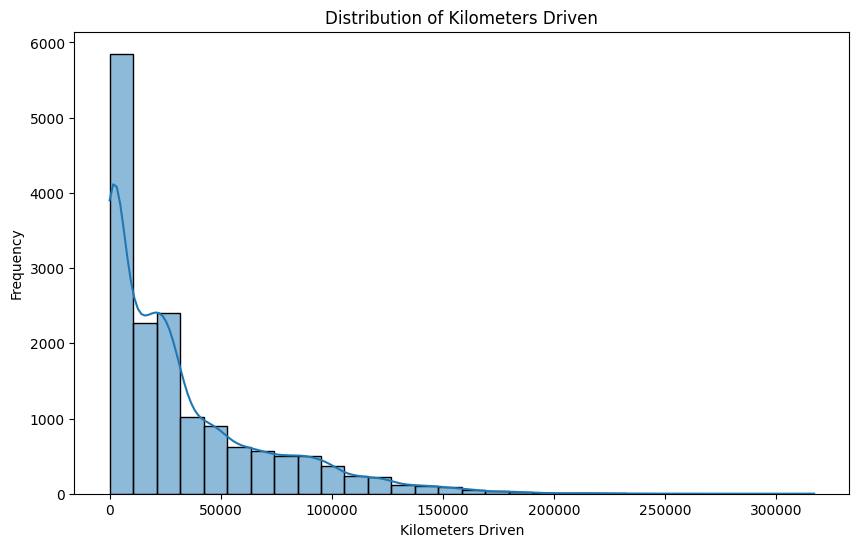

In [ ]:
# Km histogram
plt.figure(figsize=(10,6))
sns.histplot(df['km'], bins=30, kde=True)
plt.title('Distribution of Kilometers Driven')
plt.xlabel('Kilometers Driven')
plt.ylabel('Frequency')
plt.show()

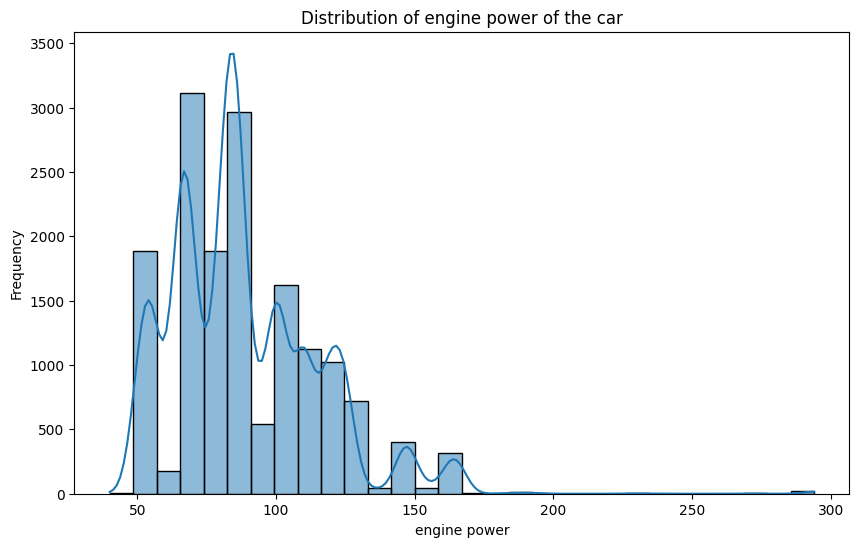

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(df['hp_kW'], bins=30, kde=True)
plt.title('Distribution of engine power of the car')
plt.xlabel('engine power')
plt.ylabel('Frequency')
plt.show()

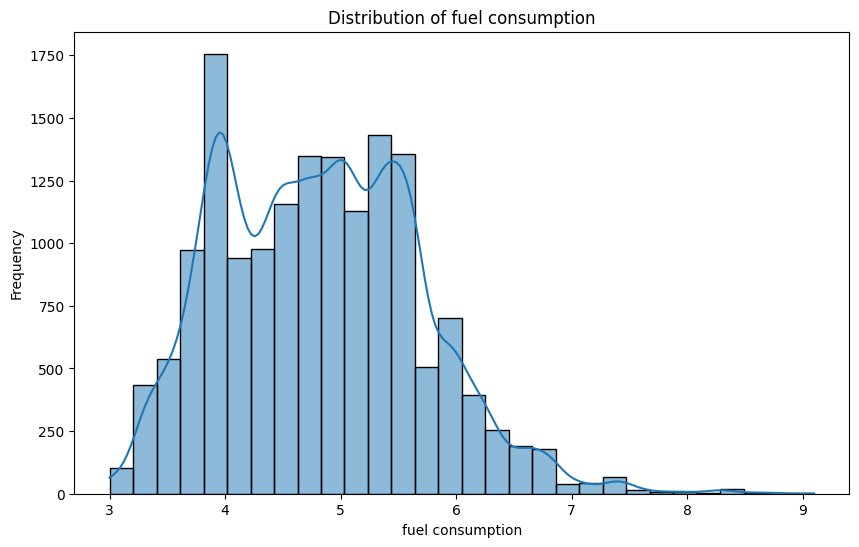

In [ ]:
# cons_comb
plt.figure(figsize=(10,6))
sns.histplot(df['cons_comb'], bins=30, kde=True)
plt.title('Distribution of fuel consumption')
plt.xlabel('fuel consumption')
plt.ylabel('Frequency')
plt.show()

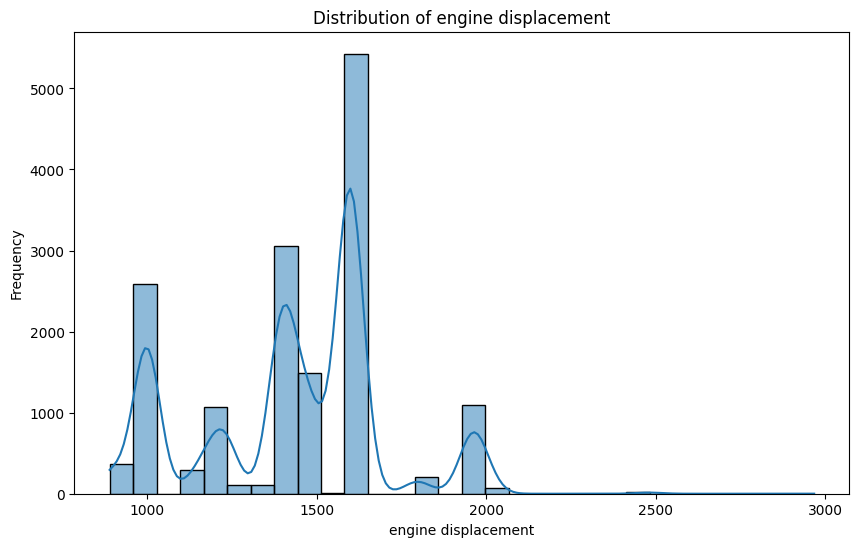

In [ ]:
# Displacement_cc
plt.figure(figsize=(10,6))
sns.histplot(df['Displacement_cc'], bins=30, kde=True)
plt.title('Distribution of engine displacement')
plt.xlabel('engine displacement')
plt.ylabel('Frequency')
plt.show()

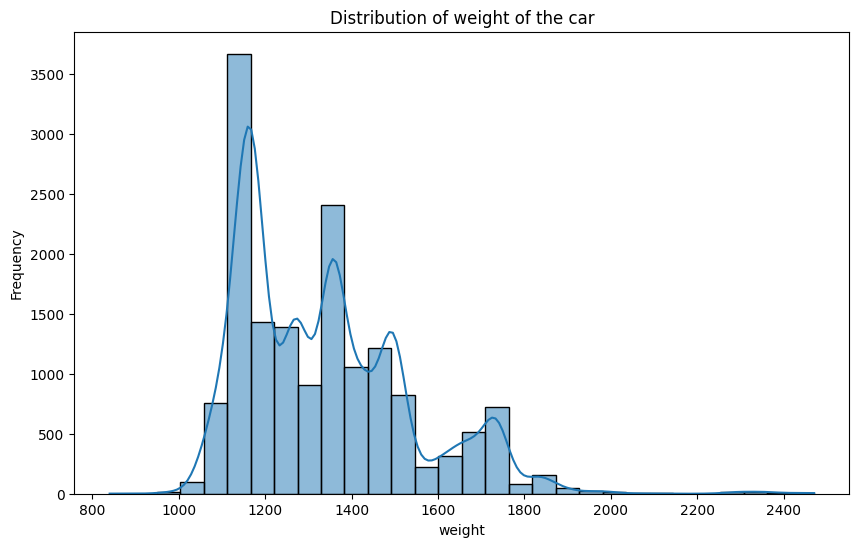

In [ ]:
# Weight_kg
plt.figure(figsize=(10,6))
sns.histplot(df['Weight_kg'], bins=30, kde=True)
plt.title('Distribution of weight of the car')
plt.xlabel('weight')
plt.ylabel('Frequency')
plt.show()

#### **2.1.3** <font color =red> [3 marks] </font>
Identify categorical predictors and plot their frequency distributions.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15915 entries, 0 to 15914
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   make_model           15915 non-null  object 
 1   body_type            15915 non-null  object 
 2   price                15915 non-null  int64  
 3   vat                  15915 non-null  object 
 4   km                   15915 non-null  float64
 5   Type                 15915 non-null  object 
 6   Fuel                 15915 non-null  object 
 7   Gears                15915 non-null  float64
 8   Comfort_Convenience  15915 non-null  object 
 9   Entertainment_Media  15915 non-null  object 
 10  Extras               15915 non-null  object 
 11  Safety_Security      15915 non-null  object 
 12  age                  15915 non-null  float64
 13  Previous_Owners      15915 non-null  float64
 14  hp_kW                15915 non-null  float64
 15  Inspection_new       15915 non-null 

In [ ]:
# Identify categorical columns and check their frequency distributions
categorical_features = ['make_model', 'body_type', 'vat', 'Type', 'Fuel', 'Gears', 'Comfort_Convenience', 'Entertainment_Media', 'Extras', 'Safety_Security', 'age', 'Previous_Owners', 'Inspection_new', 'Paint_Type', 'Upholstery_type', 'Gearing_Type', 'Drive_chain']


Let's visualize the frequency distribution of categorical features. We will skip multi-valued columns (`Comfort_Convenience`, `Entertainment_Media`, `Extras`, `Safety_Security`) for now as they require different handling.

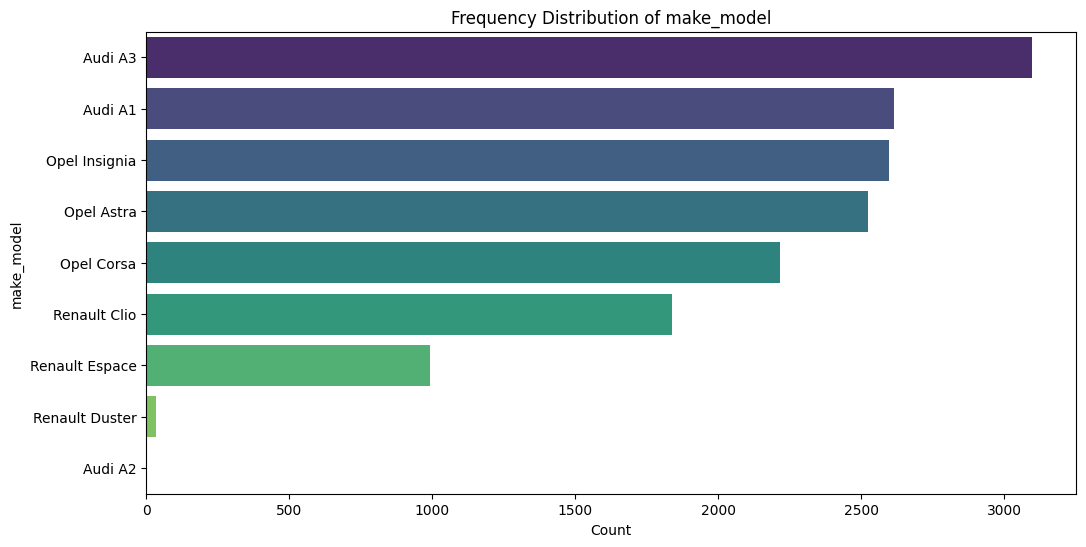

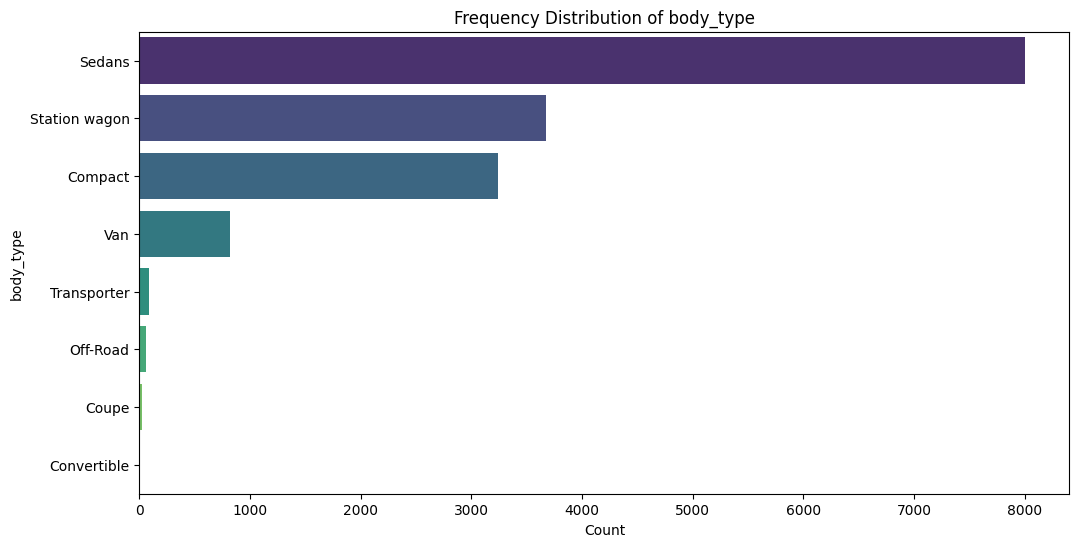

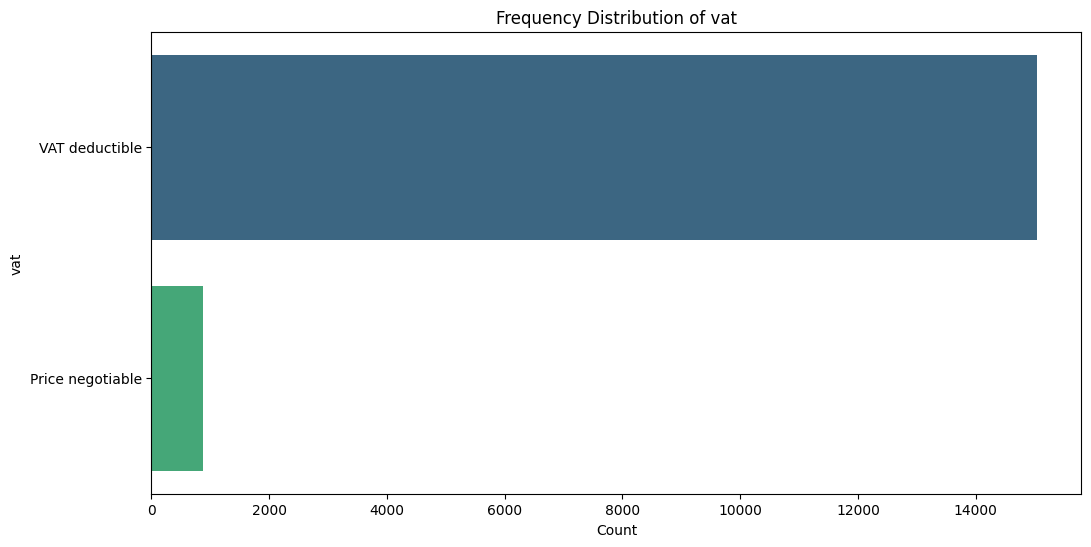

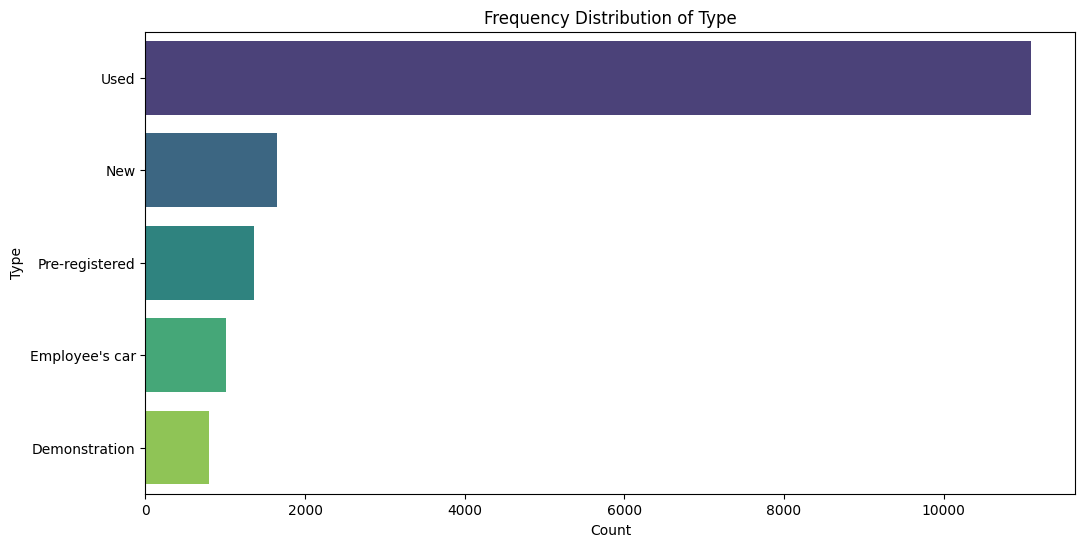

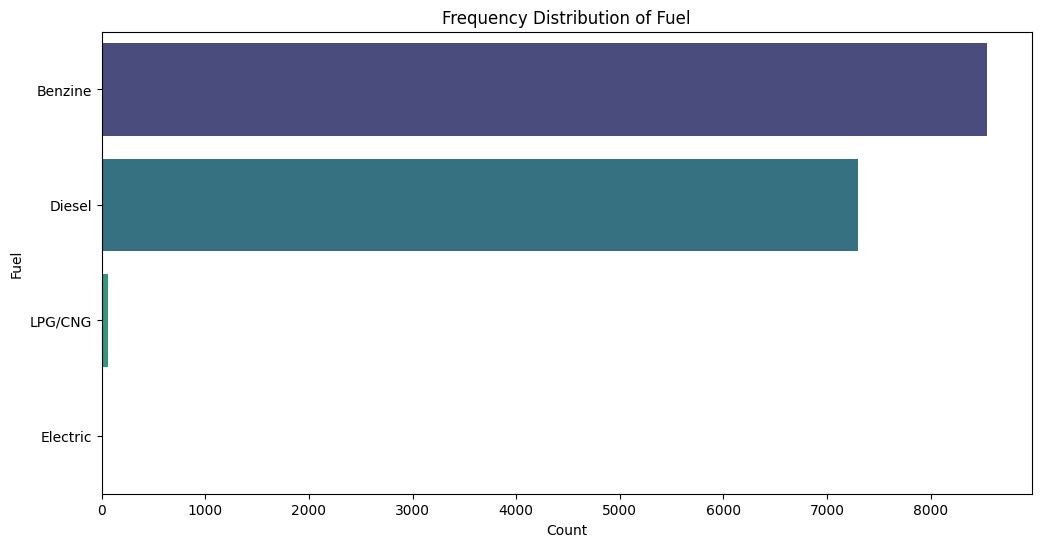

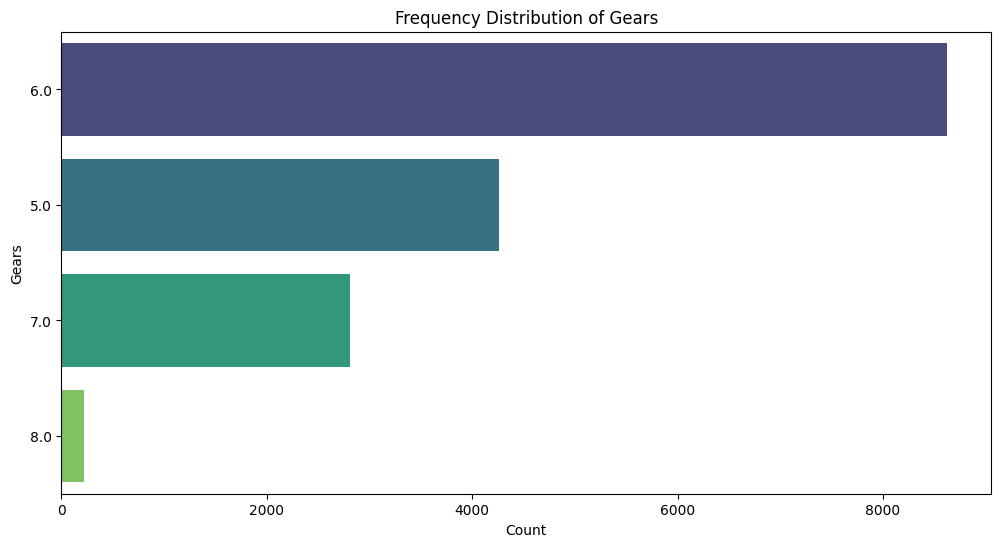

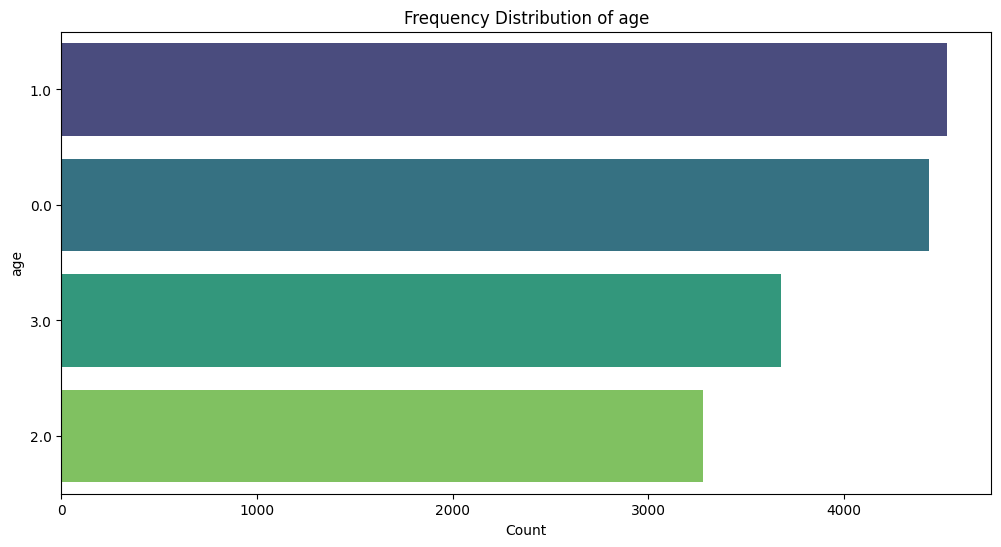

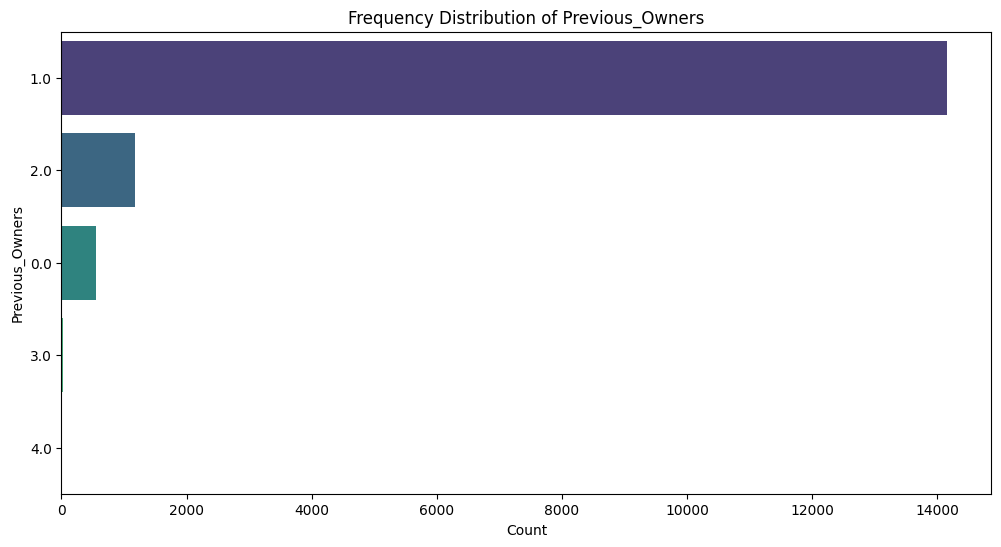

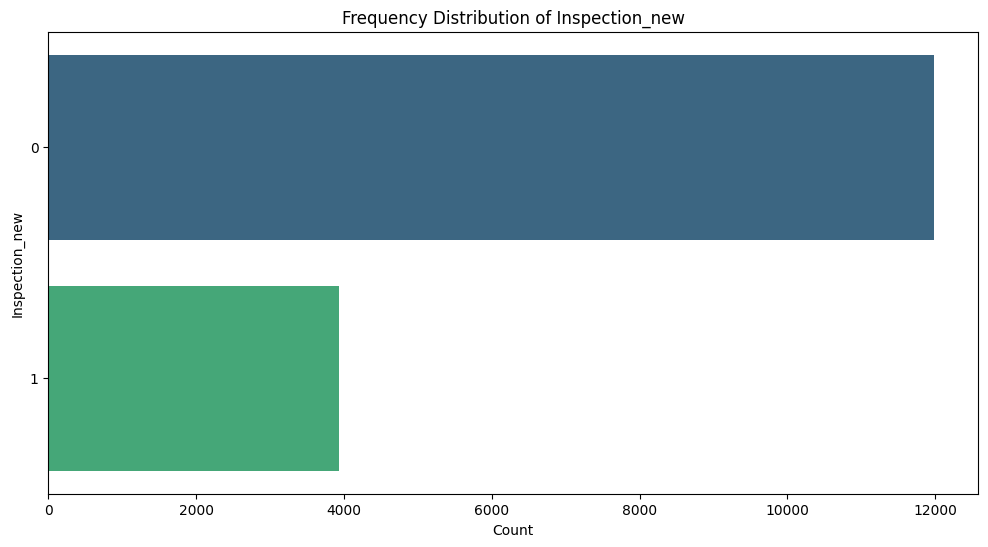

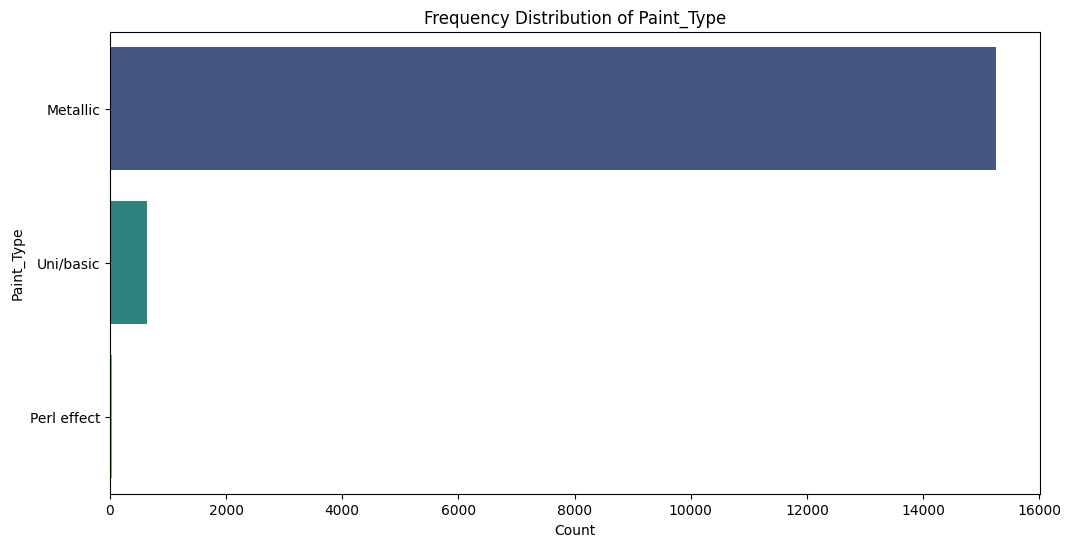

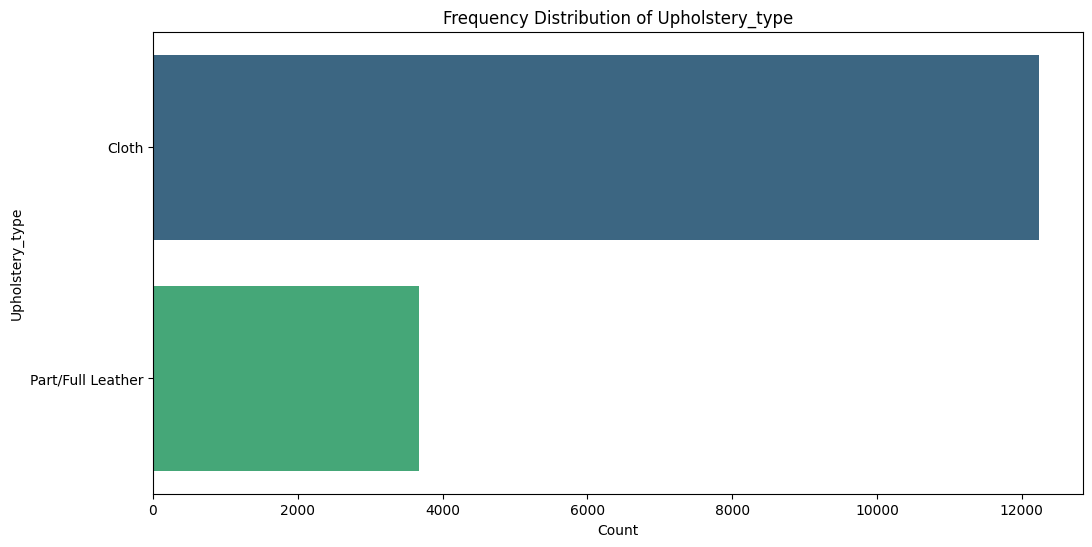

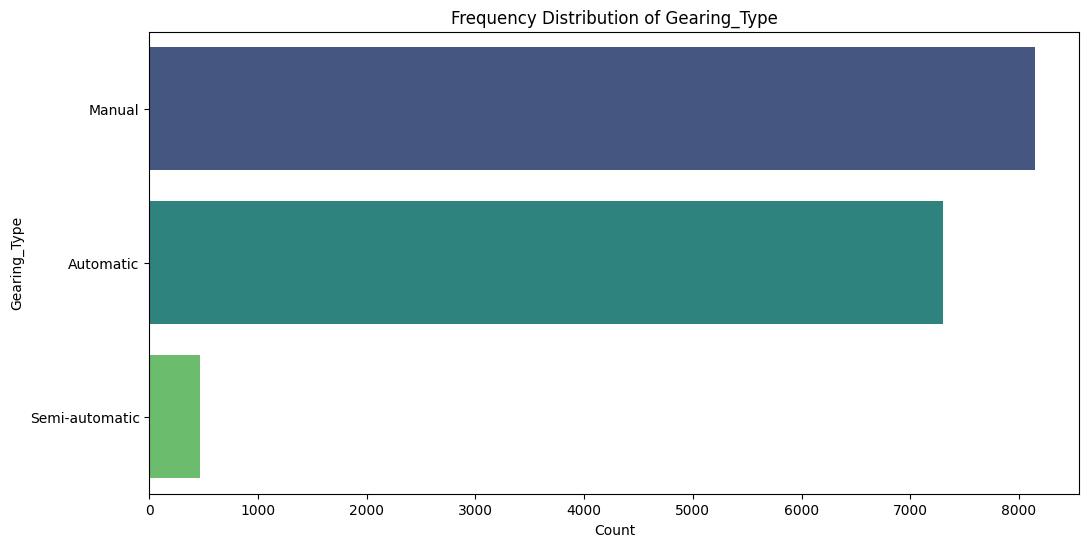

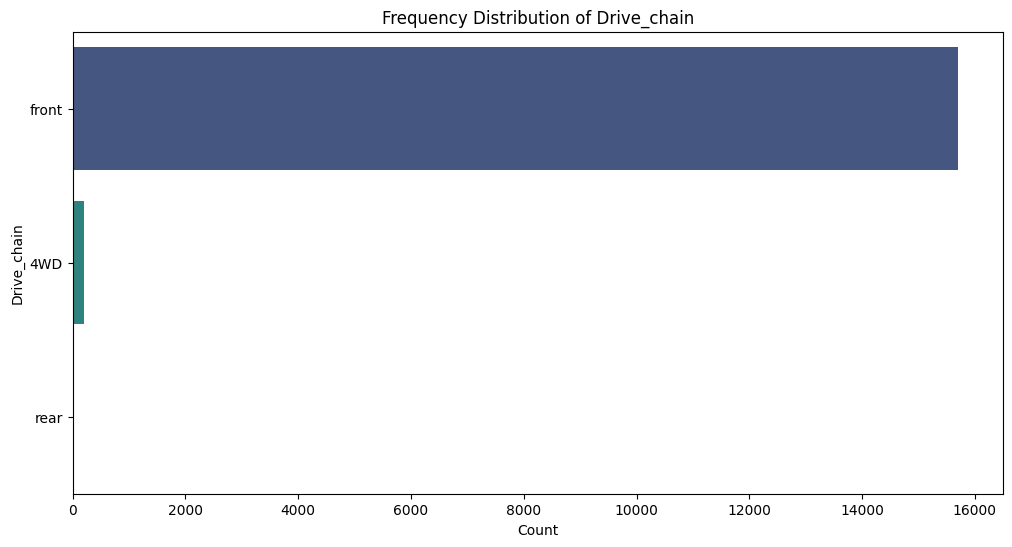

In [ ]:
multi_value_cols = ['Comfort_Convenience', 'Entertainment_Media', 'Extras', 'Safety_Security']
single_value_categorical_features = [col for col in categorical_features if col not in multi_value_cols]

for col in single_value_categorical_features:
    plt.figure(figsize=(12, 6))
    sns.countplot(data=df, y=col, order=df[col].value_counts().index, palette='viridis')
    plt.title(f'Frequency Distribution of {col}')
    plt.xlabel('Count')
    plt.ylabel(col)
    plt.show()

**Note**: Look carefully at the values stored in columns `["Comfort_Convenience", "Entertainment_Media", "Extras", "Safety_Security"]`.

Should they be considered categorical? Should they be dropped or handled any other way?

In [ ]:
# these features is having comma separated properties, which can be handled by keeping frequencies of the accurance of each property. Will do it in the feature engineering

#### **2.1.4** <font color =red> [3 marks] </font>
Fix columns with low frequency values and class imbalances.

Some information regarding values in the `Type` column that may help:
- *'Pre-registered'* cars are ones which have already been registered previously by the seller.
- *'New'* cars are not necessarily new cars, but new-like cars. These might also have multiple owners due to multiple pre-registrations as well.
- *'Employee's car'* are cars used by employees over a short period of time and small distance.
- *'Demonstration'* cars are used for trial purposes and also driven for a short time and distance.

Based on these, you can handle this particular column. For other columns, decide a strategy on your own.

In [ ]:
# Fix Type column
df['Type'].value_counts()


,count
Type,
Used,11095
New,1649
Pre-registered,1364
Employee's car,1011
Demonstration,796


In [ ]:
# Combine low-frequency categories in 'Type' column
df['Type'] = df['Type'].replace(['New', 'Pre-registered', "Employee's car", 'Demonstration'], 'Almost New')

# Display the new value counts for 'Type' to verify
display(df['Type'].value_counts())

,count
Type,
Used,11095
Almost New,4820


In [ ]:
# make_model
df['make_model'].value_counts()

,count
make_model,
Audi A3,3097
Audi A1,2614
Opel Insignia,2598
Opel Astra,2525
Opel Corsa,2216
Renault Clio,1839
Renault Espace,991
Renault Duster,34
Audi A2,1


In [ ]:
# combining all based on the make of the car
df['make_model']=df['make_model'].apply(lambda x: x.split()[0])
df['make_model'].value_counts()

,count
make_model,
Opel,7339
Audi,5712
Renault,2864


In [ ]:
# body_type
df['body_type'].value_counts()

,count
body_type,
Sedans,8004
Station wagon,3677
Compact,3240
Van,817
Transporter,88
Off-Road,56
Coupe,25
Convertible,8


In [ ]:
# Combine low-frequency categories in 'body_type' column into 'Other'
low_frequency_body_types = ['Transporter', 'Off-Road', 'Coupe', 'Convertible', 'Van']
df['body_type'] = df['body_type'].replace(low_frequency_body_types, 'Other')

# Display the new value counts for 'body_type' to verify
display(df['body_type'].value_counts())

,count
body_type,
Sedans,8004
Station wagon,3677
Compact,3240
Other,994


In [ ]:
# vat, No parity here
df['vat'].value_counts()

,count
vat,
VAT deductible,15044
Price negotiable,871


In [ ]:
# Fuel
df['Fuel'].value_counts()

,count
Fuel,
Benzine,8548
Diesel,7298
LPG/CNG,64
Electric,5


In [ ]:
# Combine low-frequency categories in 'Fuel' column into 'Other'
low_frequency_fuel_types = ['LPG/CNG', 'Electric']
df['Fuel'] = df['Fuel'].replace(low_frequency_fuel_types, 'Other')

# Display the new value counts for 'Fuel' to verify
display(df['Fuel'].value_counts())

,count
Fuel,
Benzine,8548
Diesel,7298
Other,69


In [ ]:
# Gears column does not need any fix
df['Gears'].value_counts()

,count
Gears,
6.0,8623
5.0,4257
7.0,2810
8.0,225


In [ ]:
# Converting to String
df['Gears']=df.Gears.apply(lambda x: str(x).split('.')[0])
df['Gears'].value_counts()

,count
Gears,
6,8623
5,4257
7,2810
8,225


In [ ]:
# age - dont need any fix,
df['age'].value_counts()

,count
age,
1.0,4526
0.0,4433
3.0,3679
2.0,3277


In [ ]:
# converting to string
df['age']=df.age.apply(lambda x: str(x).split('.')[0])
df['age'].value_counts()

,count
age,
1,4526
0,4433
3,3679
2,3277


In [ ]:
# Previous_Owner
df['Previous_Owners'].value_counts()

,count
Previous_Owners,
1.0,14158
2.0,1172
0.0,554
3.0,29
4.0,2


In [ ]:
# combining less frequent 3 and 4 owner to 3+ category
df['Previous_Owners']=df['Previous_Owners'].apply(lambda x: str(x).split('.')[0]).replace(['3','4'],'3+')
df['Previous_Owners'].value_counts()

,count
Previous_Owners,
1,14158
2,1172
0,554
3+,31


In [ ]:
# Inspection_new - no fix required
df['Inspection_new'].value_counts()

,count
Inspection_new,
0,11983
1,3932


In [ ]:
# convert to String
df['Inspection_new']=df.Inspection_new.apply(lambda x: str(x)[0])
df['Inspection_new'].value_counts()

,count
Inspection_new,
0,11983
1,3932


In [ ]:
# Paint_Type
df['Paint_Type'].value_counts()

,count
Paint_Type,
Metallic,15246
Uni/basic,637
Perl effect,32


In [ ]:
df['Paint_Type']=df['Paint_Type'].replace(['Uni/basic','Perl effect'],'Others')
df['Paint_Type'].value_counts()

,count
Paint_Type,
Metallic,15246
Others,669


In [ ]:
# Upholstery_type - dont need any fix
df['Upholstery_type'].value_counts()

,count
Upholstery_type,
Cloth,12234
Part/Full Leather,3681


In [ ]:
#Gearing_Type - Dont need any fix
df['Gearing_Type'].value_counts()

,count
Gearing_Type,
Manual,8149
Automatic,7297
Semi-automatic,469


In [ ]:
#Drive_chain
df['Drive_chain'].value_counts()

,count
Drive_chain,
front,15707
4WD,204
rear,4


In [ ]:
low_frequency_drive_chain = ['4WD', 'rear']
df['Drive_chain'] = df['Drive_chain'].replace(low_frequency_drive_chain, 'Other')

# Display the new value counts for 'Drive_chain' to verify
display(df['Drive_chain'].value_counts())

,count
Drive_chain,
front,15707
Other,208


#### **2.1.5** <font color =red> [3 marks] </font>
Identify target variable and plot the frequency distributions. Apply necessary transformations.

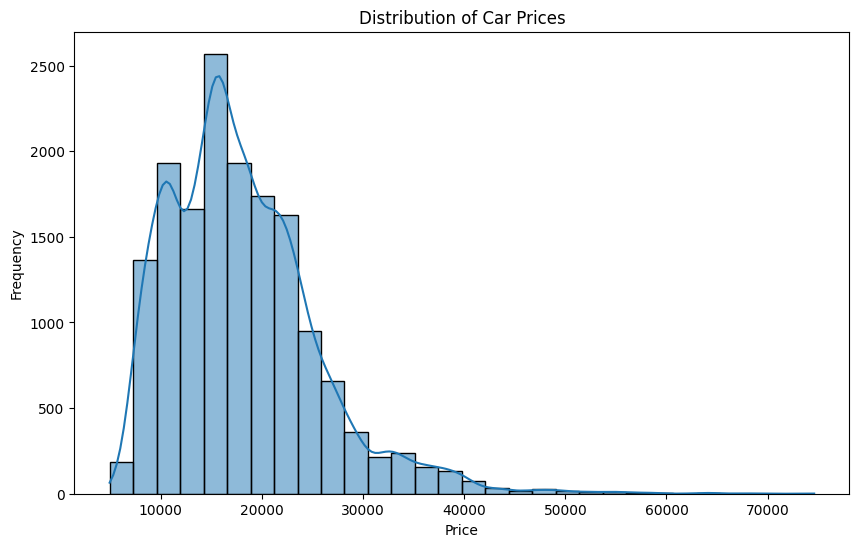

In [ ]:
# Plot histograms for target feature
plt.figure(figsize=(10, 6))
sns.histplot(df['price'], bins=30, kde=True)
plt.title('Distribution of Car Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

**The target variable seems to be skewed. Perform suitable transformation on the target.**

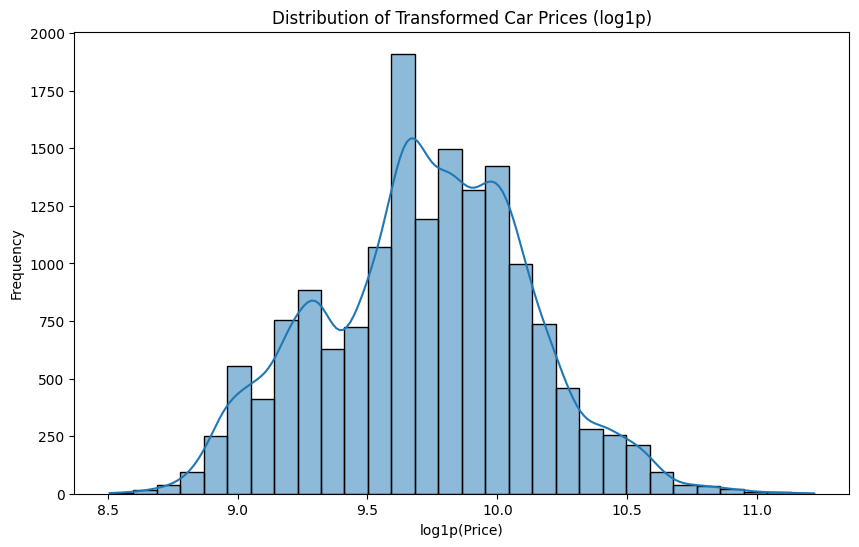

In [ ]:
# Transform the target feature
# The price variable is right skewed, to fix this log transform

df['price_log'] = np.log1p(df['price'])

plt.figure(figsize=(10, 6))
sns.histplot(df['price_log'], bins=30, kde=True)
plt.title('Distribution of Transformed Car Prices (log1p)')
plt.xlabel('log1p(Price)')
plt.ylabel('Frequency')
plt.show()

In [ ]:
df[['price','price_log']]

,price,price_log
0,15770,9.665928
1,14500,9.581973
2,14640,9.591581
3,14500,9.581973
4,16790,9.728598
...,...,...
15910,39950,10.595409
15911,39885,10.593781
15912,39875,10.593530
15913,39700,10.589132


### **2.2 Correlation analysis** <font color = red> [6 marks] </font>

#### **2.2.1** <font color =red> [3 marks] </font>
Plot the correlation map between features and target variable.

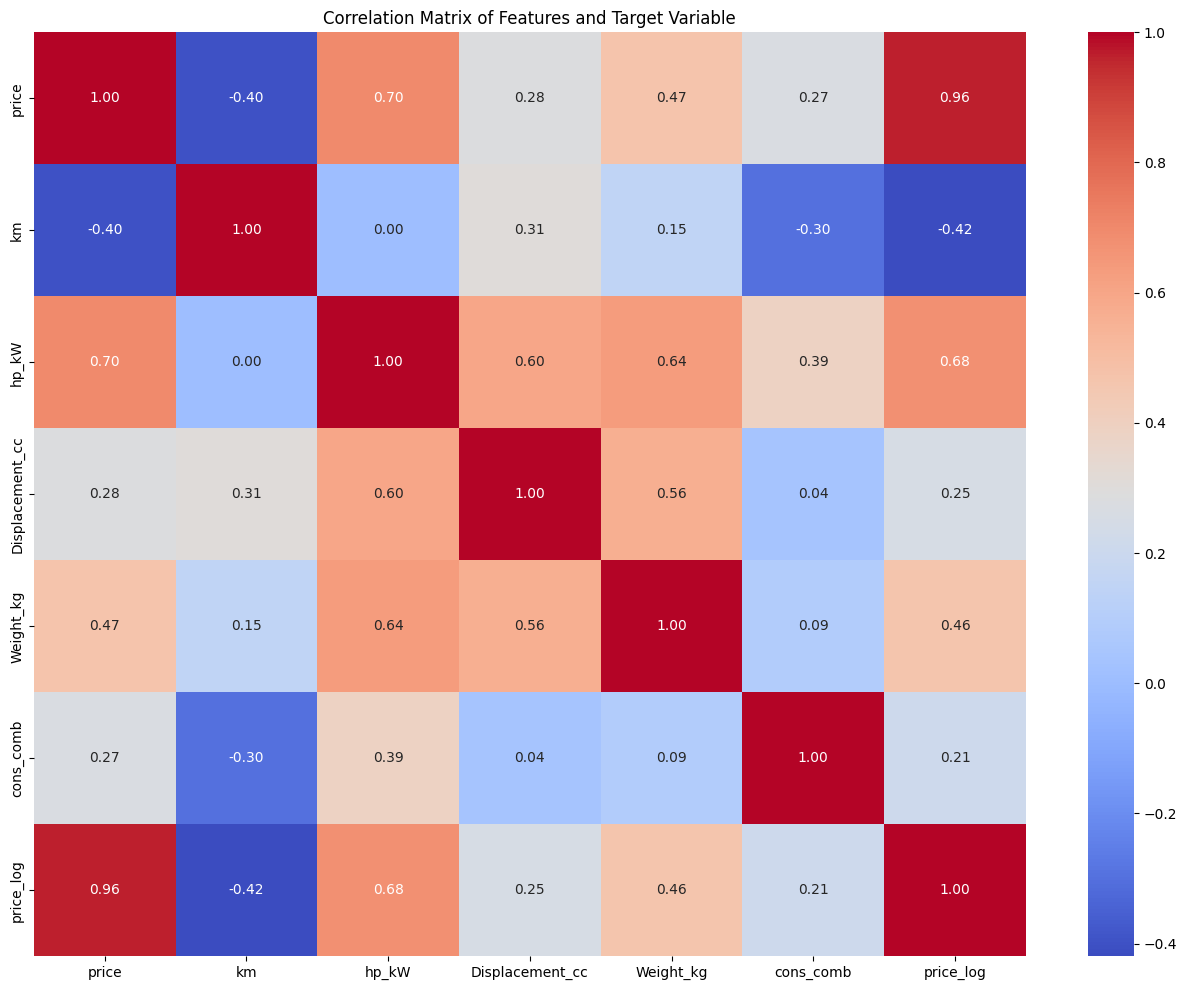

In [ ]:
# Visualise correlation

plt.figure(figsize=(16, 12))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Features and Target Variable')
plt.show()

## Observation
target variable: price_log
numeric predictor: Km, hp_kW, Dispacement_cc, Weight_kg, cons_comb (Fuel consumption)
Among which,


*   km is -vely correlated, meaning - less km driven higher the price
*   hp_kW : +ve - more power more will be the price
*   Displacement_cc: not strong but positive - more the cc more will be price
*   Weight_kg: +ve - more the wight more will be the price
*   cons_comb: not string but positive - moer priced cars will consume more fuel




#### **2.2.2** <font color =red> [3 marks] </font>
Analyse correlation between categorical features and target variable.

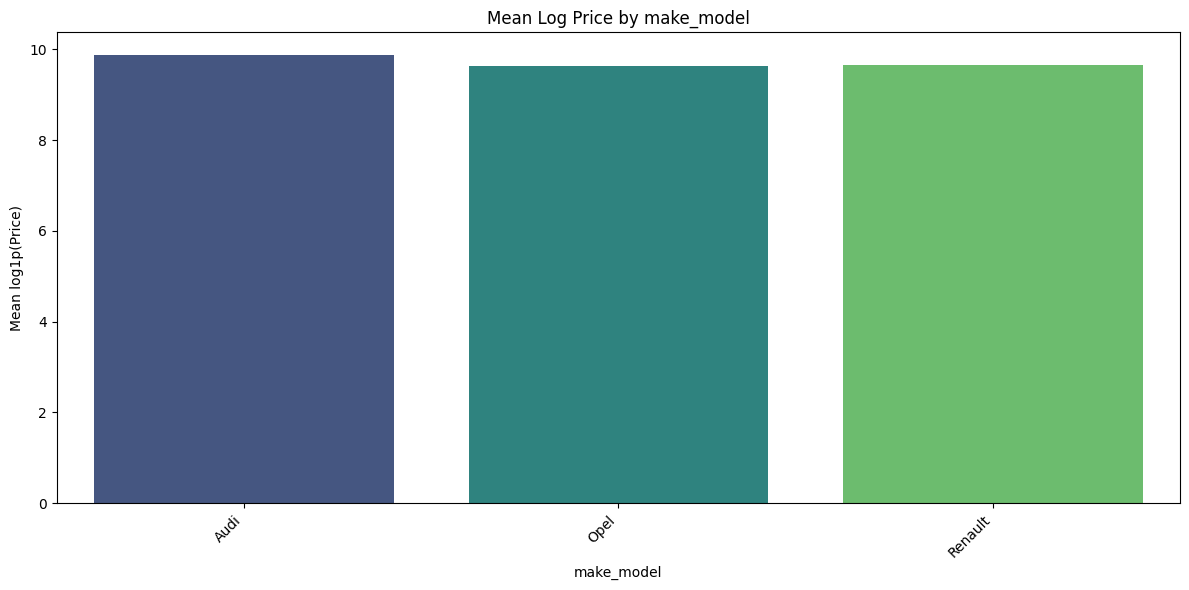

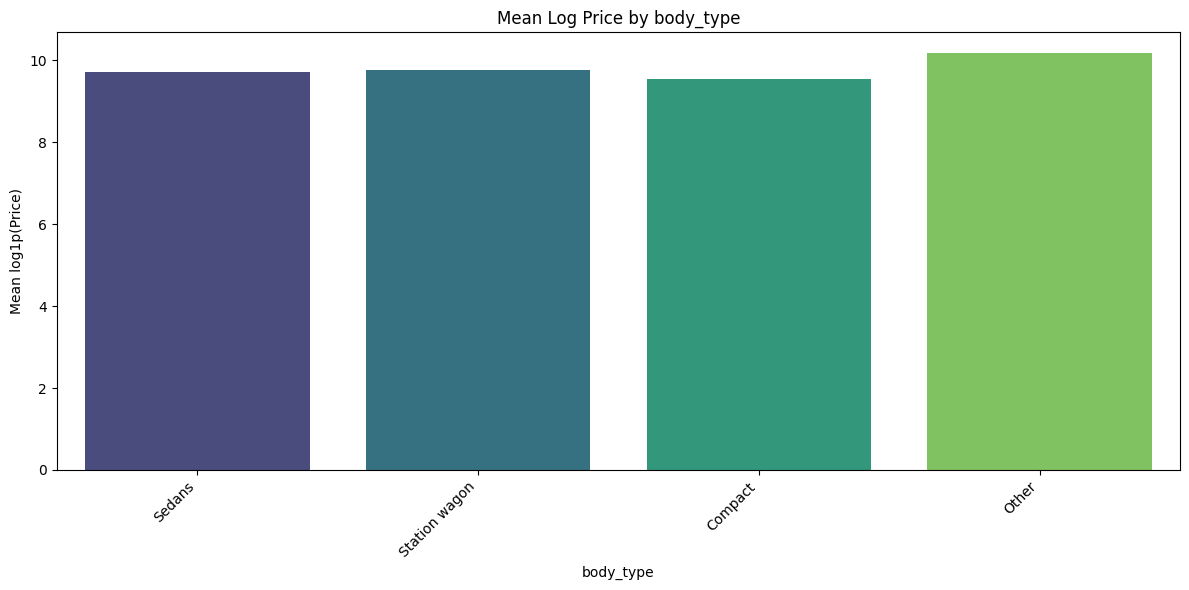

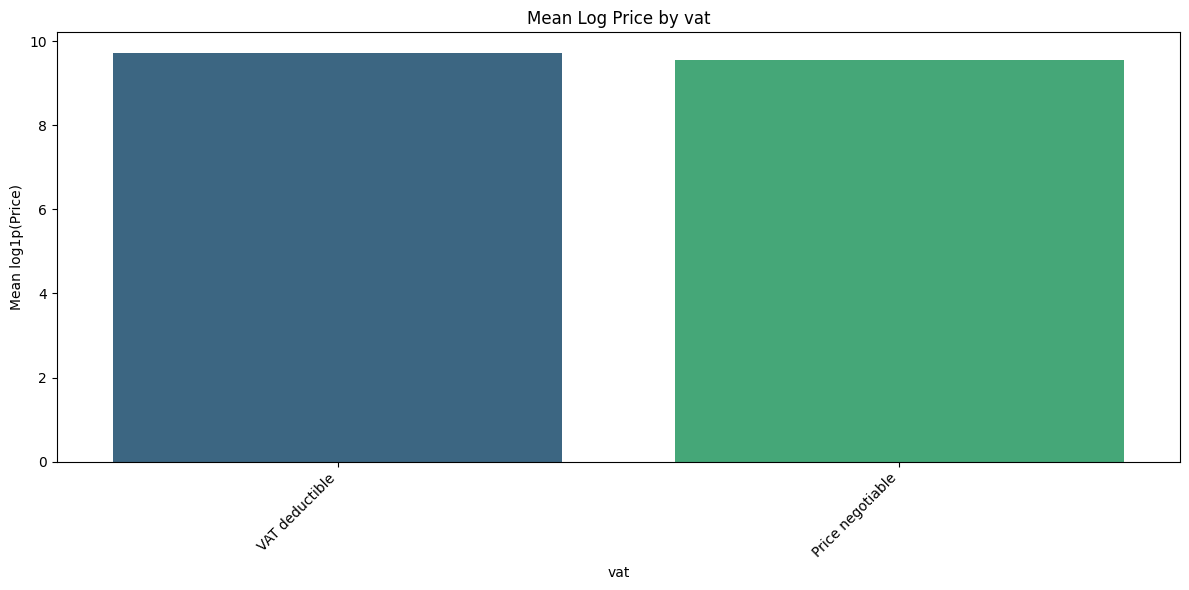

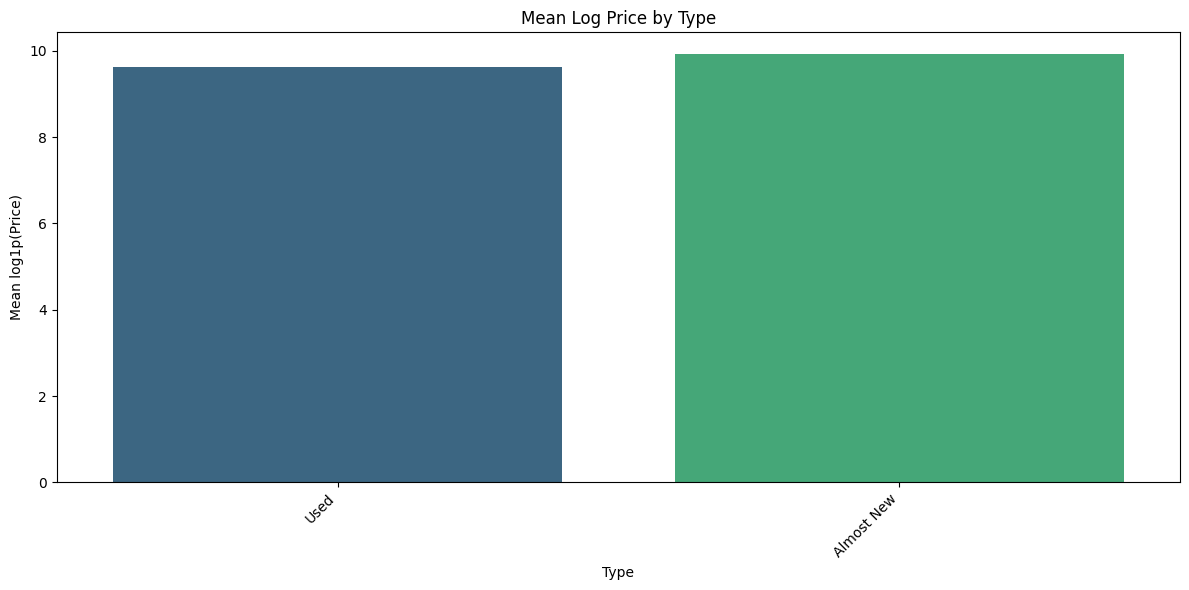

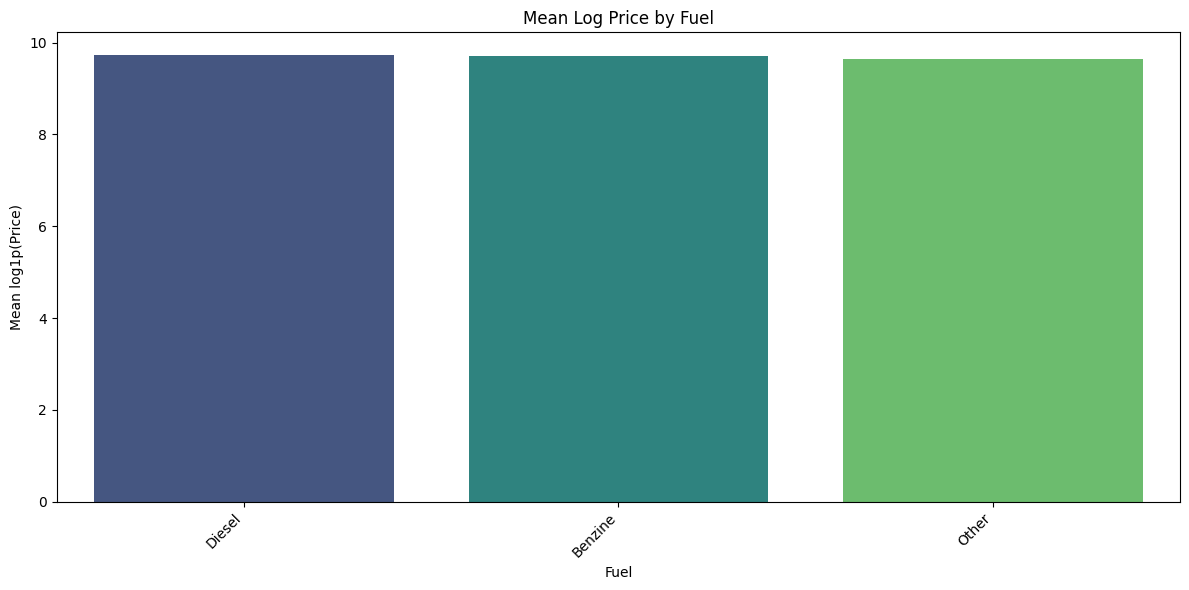

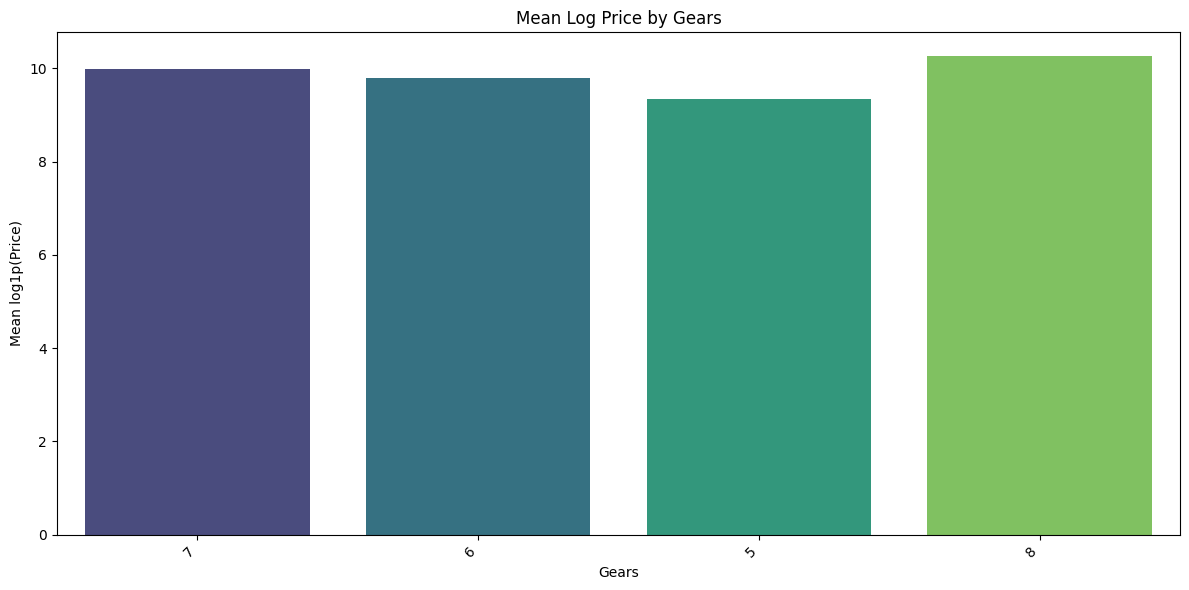

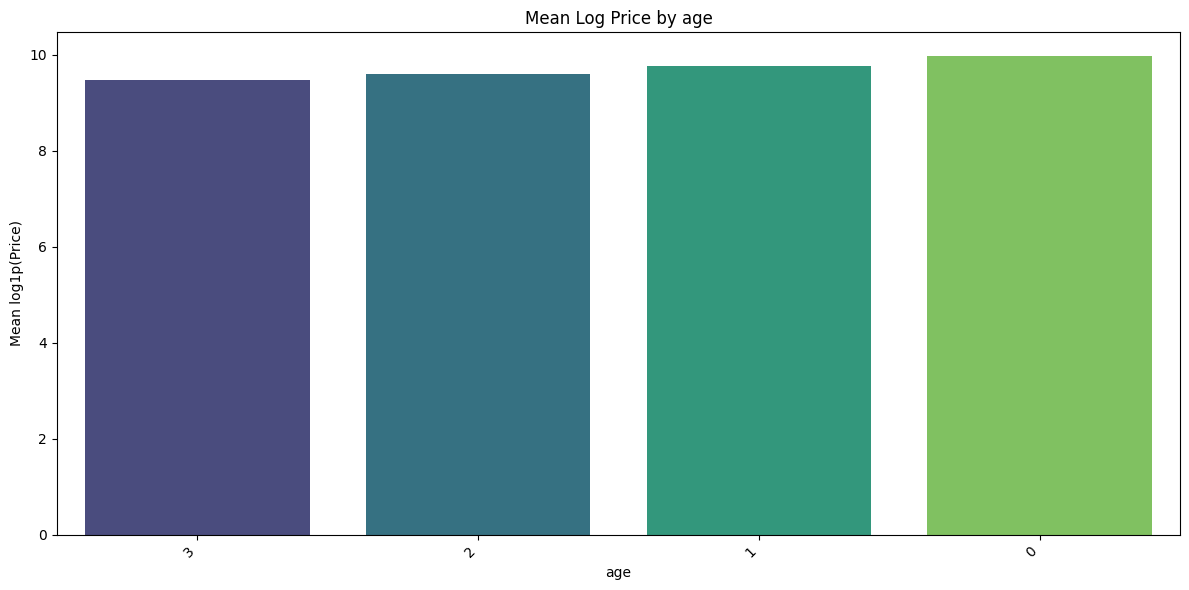

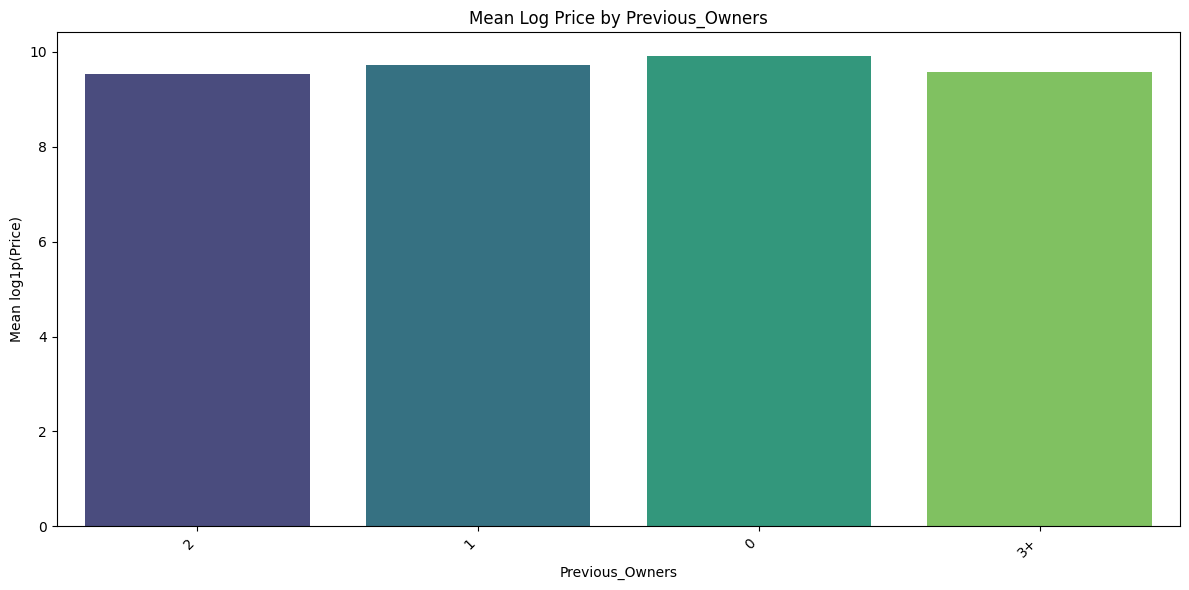

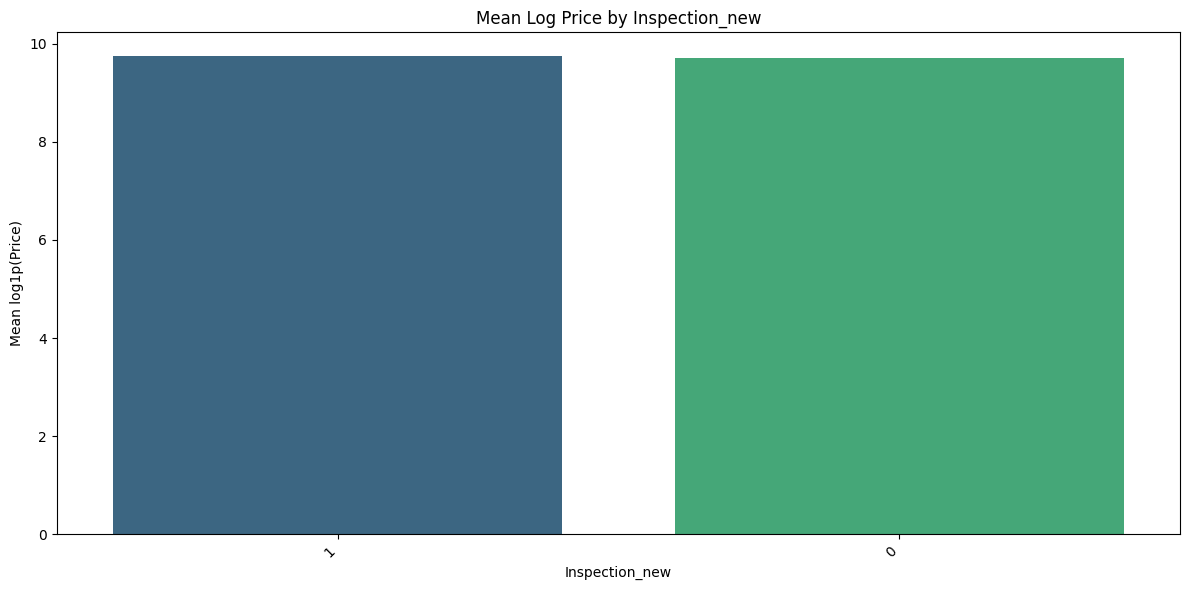

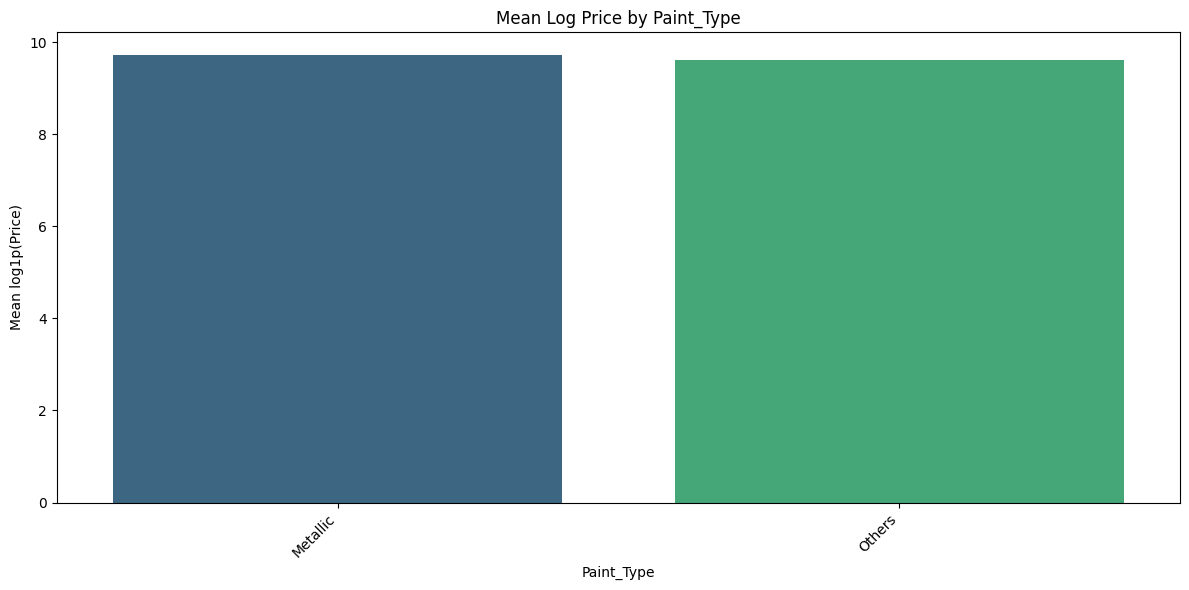

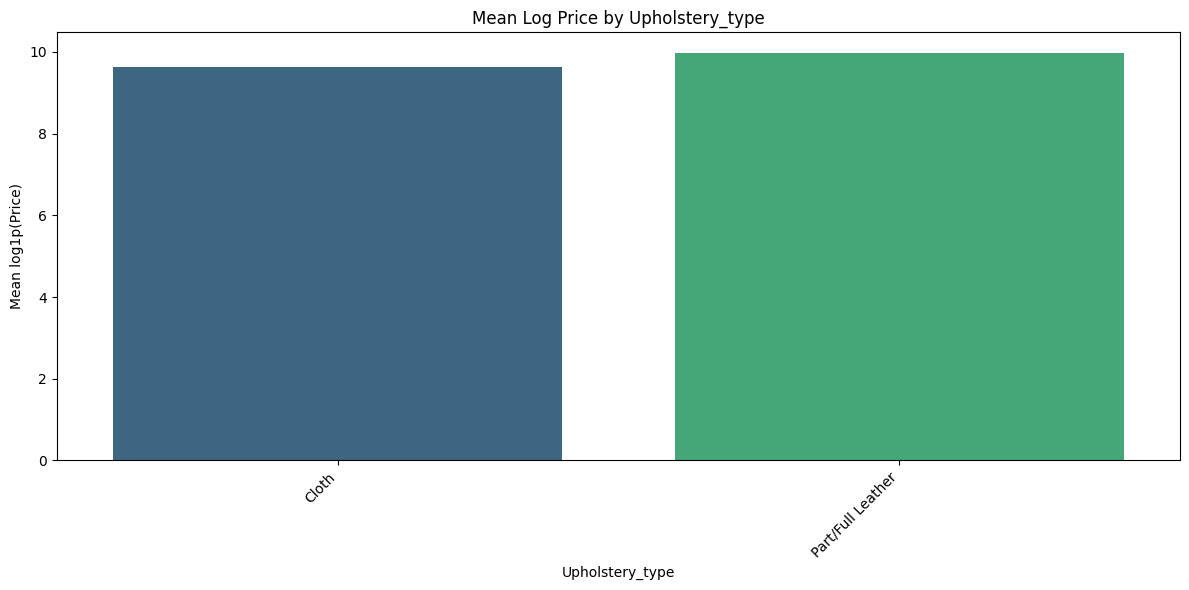

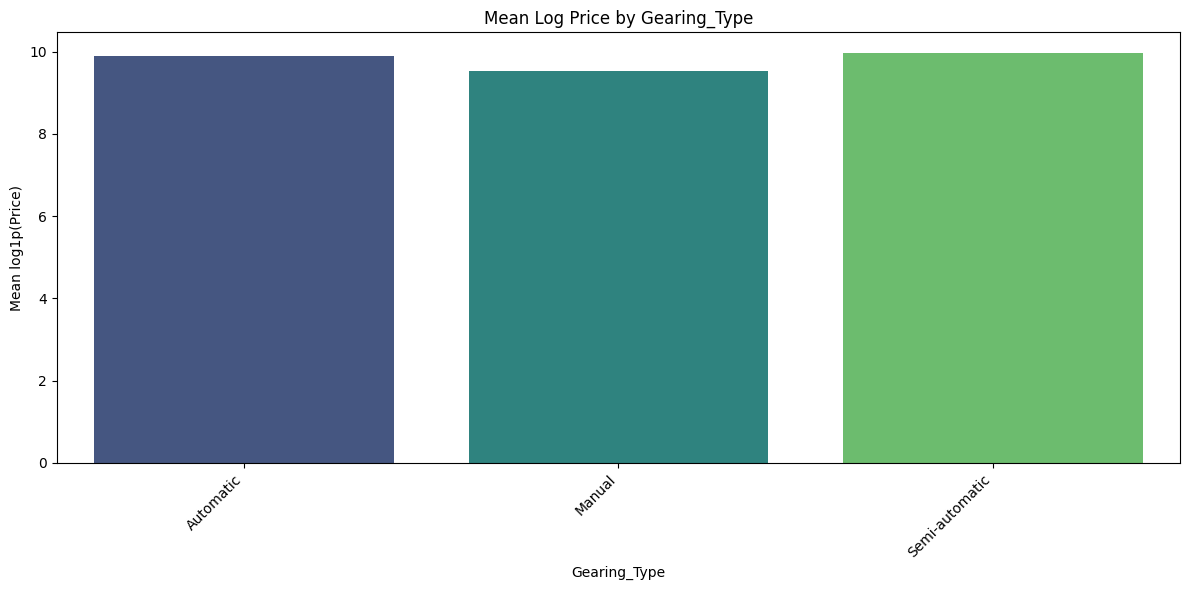

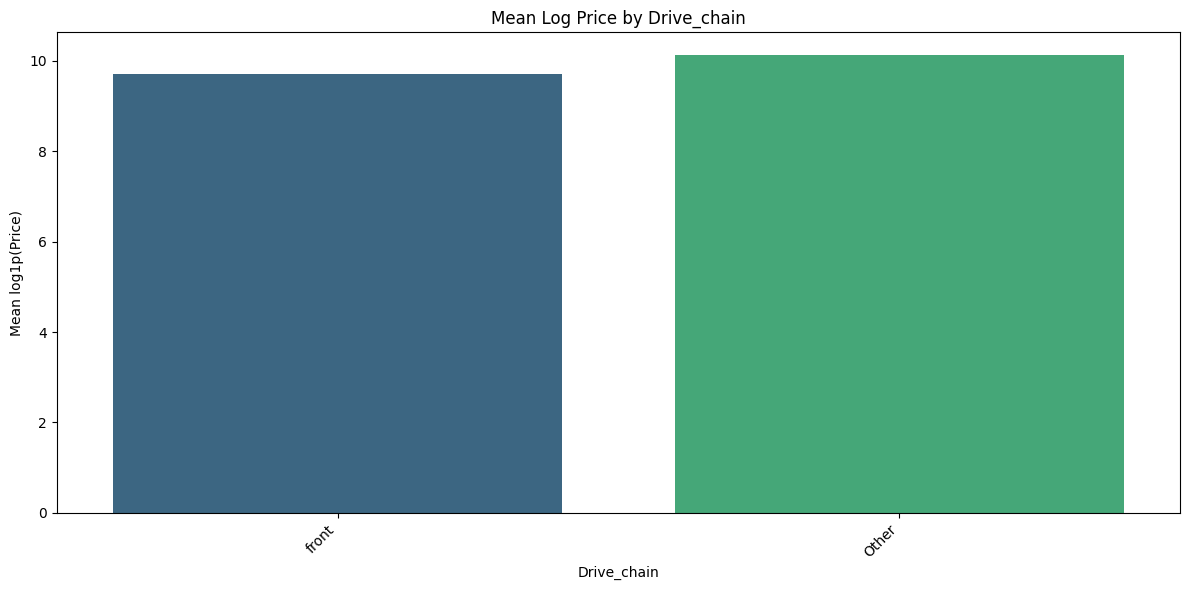

In [ ]:
# Comparing average values of target for different categories
for col in single_value_categorical_features:
    plt.figure(figsize=(12, 6))
    sns.barplot(data=df, x=col, y='price_log', palette='viridis', ci=None)
    plt.title(f'Mean Log Price by {col}')
    plt.xlabel(col)
    plt.ylabel('Mean log1p(Price)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


### **2.3 Outlier analysis** <font color = red> [5 marks] </font>

#### **2.3.1** <font color =red> [2 marks] </font>
Identify potential outliers in the data.

In [ ]:
# Outliers present in each column
numerical_features = ['km', 'hp_kW', 'Displacement_cc', 'Weight_kg', 'cons_comb', 'price_log']
df[numerical_features].describe()

,km,hp_kW,Displacement_cc,Weight_kg,cons_comb,price_log
count,15915.000000,15915.000000,15915.000000,15915.000000,15915.000000,15915.000000
mean,32089.995708,88.499340,1428.661891,1337.700534,4.832124,9.720764
std,36977.214964,26.674341,275.804272,199.682385,0.867530,0.398222
min,0.000000,40.000000,890.000000,840.000000,3.000000,8.507345
25%,1920.500000,66.000000,1229.000000,1165.000000,4.100000,9.461177
50%,20413.000000,85.000000,1461.000000,1295.000000,4.800000,9.735128
75%,46900.000000,103.000000,1598.000000,1472.000000,5.400000,9.994288
max,317000.000000,294.000000,2967.000000,2471.000000,9.100000,11.219909


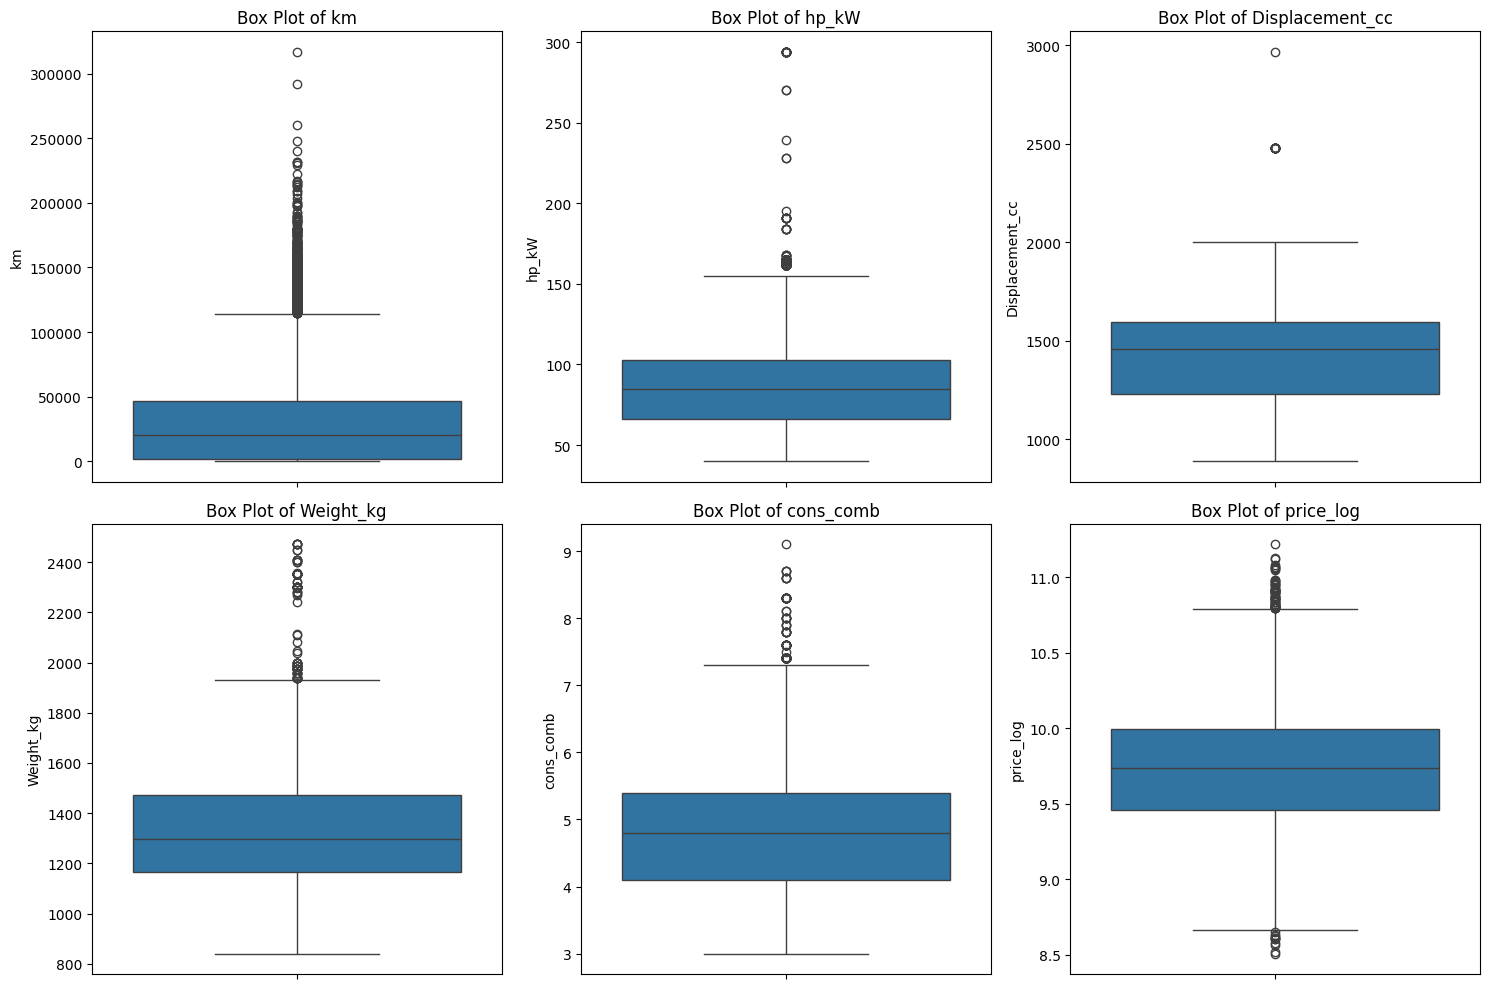

In [ ]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_features, 1):
    plt.subplot(2, 3, i) # Adjust subplot grid as needed
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

#### **2.3.2** <font color =red> [3 marks] </font>
Handle the outliers suitably.

In [ ]:
# Handle outliers
# handling of km

We will use the Interquartile Range (IQR) method to define bounds for outlier detection and then cap the values that fall outside these bounds.

Outliers in 'km' capped at Lower Bound: -65548.75, Upper Bound: 114369.25
Outliers in 'hp_kW' capped at Lower Bound: 10.50, Upper Bound: 158.50
Outliers in 'Displacement_cc' capped at Lower Bound: 675.50, Upper Bound: 2151.50
Outliers in 'Weight_kg' capped at Lower Bound: 704.50, Upper Bound: 1932.50
Outliers in 'cons_comb' capped at Lower Bound: 2.15, Upper Bound: 7.35
Outliers in 'price_log' capped at Lower Bound: 8.66, Upper Bound: 10.79


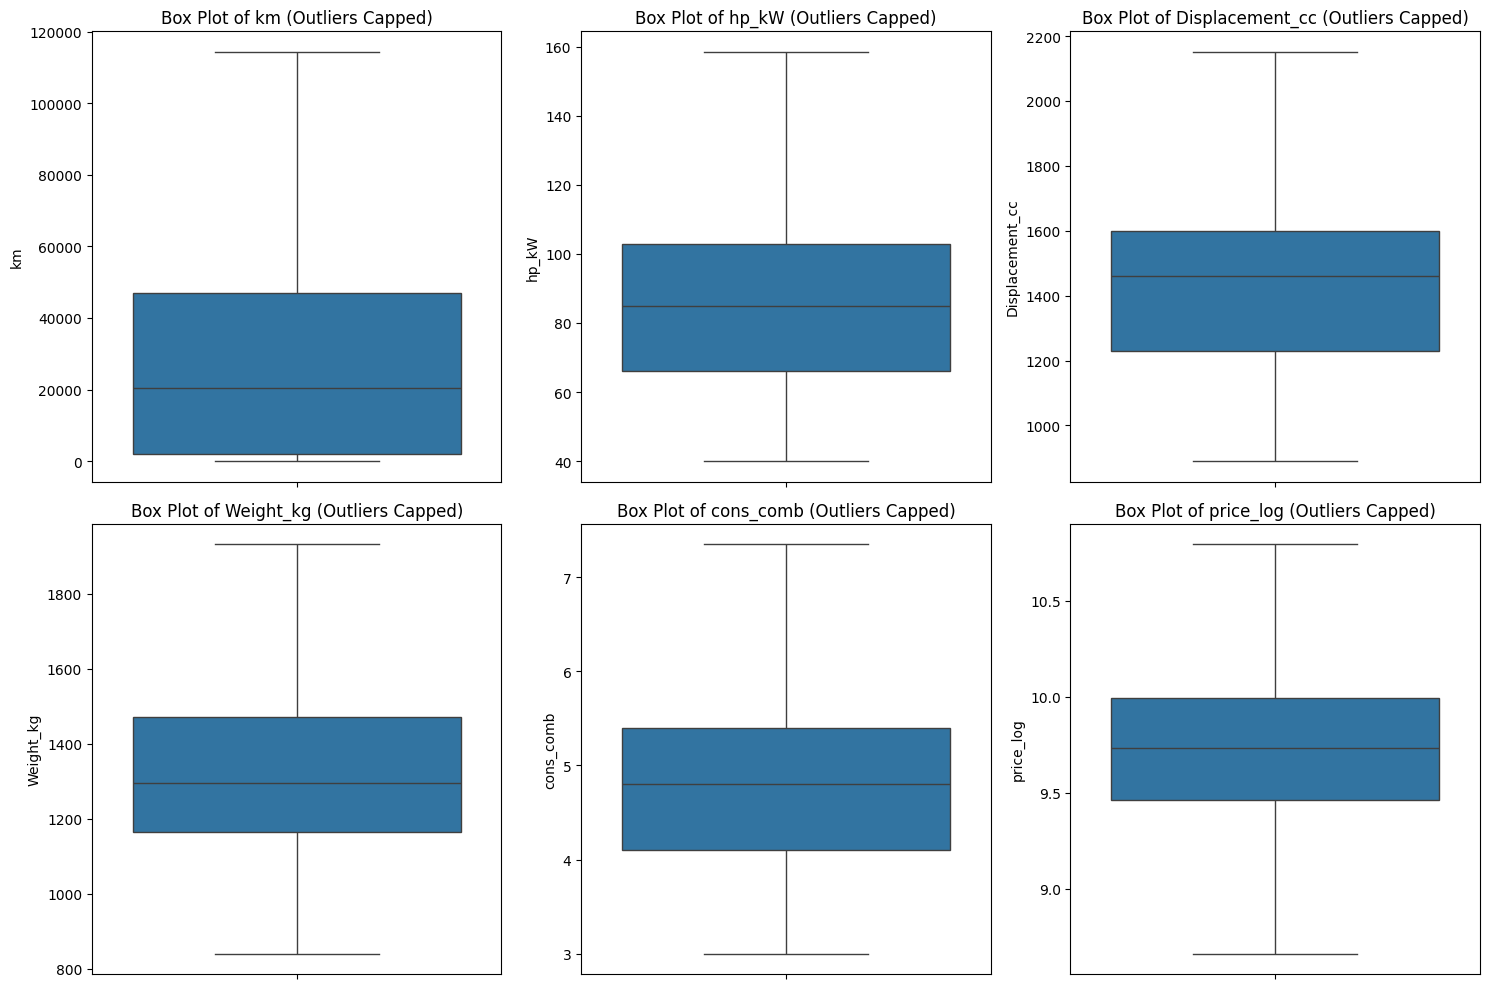

In [ ]:
for col in numerical_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    # Define outlier bounds
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Cap outliers at the bounds
    df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
    df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])

    print(f"Outliers in '{col}' capped at Lower Bound: {lower_bound:.2f}, Upper Bound: {upper_bound:.2f}")

# Display box plots again to verify outlier handling
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_features, 1):
    plt.subplot(2, 3, i) # Adjust subplot grid as needed
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot of {col} (Outliers Capped)')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15915 entries, 0 to 15914
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   make_model           15915 non-null  object 
 1   body_type            15915 non-null  object 
 2   price                15915 non-null  int64  
 3   vat                  15915 non-null  object 
 4   km                   15915 non-null  float64
 5   Type                 15915 non-null  object 
 6   Fuel                 15915 non-null  object 
 7   Gears                15915 non-null  object 
 8   Comfort_Convenience  15915 non-null  object 
 9   Entertainment_Media  15915 non-null  object 
 10  Extras               15915 non-null  object 
 11  Safety_Security      15915 non-null  object 
 12  age                  15915 non-null  object 
 13  Previous_Owners      15915 non-null  object 
 14  hp_kW                15915 non-null  float64
 15  Inspection_new       15915 non-null 

### **2.4 Feature Engineering** <font color = red> [11 marks] </font>

#### **2.4.1**
Fix any redundant columns and create new ones if needed.

In [ ]:
# Fix/create columns as needed



#### **2.4.2** <font color =red> [4 marks] </font>
Analysis and feature engineering on `['Comfort_Convenience', 'Entertainment_Media', 'Extras', 'Safety_Security']`.

These columns contains lists of features present. Decide on how to include these features in the predictors.

For multi-valued categorical features, it's common to create binary (dummy) variables for each unique item. However, creating a binary feature for every single item might lead to a very high-dimensional dataset, especially for items that appear very rarely or almost universally.

Here, we will iterate through each multi-valued column, extract individual features, and create a new binary column for each feature that meets certain frequency criteria (e.g., not too rare and not too common). This approach helps in capturing the presence or absence of specific features while managing the dimensionality.

We will define `min_proportion = 30%` (minimum proportion of occurrences for an item to become a new feature) and `max_proportion = 90%` (maximum proportion of occurrences for an item to become a new feature, to exclude almost universal features).

Out of these features, we will check the ones which are present in most of the cars or are absent from most of the cars. These kinds of features can be removed as they just increase the dimensionality without explaining the variance.

In [ ]:
import numpy as np

# Define thresholds for creating new binary features
min_frequency = 0.3  # Minimum proportion of occurrences for an item to become a new feature
max_proportion = 0.9  # Maximum proportion of occurrences (to exclude features present in almost all cars)

# List of multi-valued columns
multi_value_cols = ['Comfort_Convenience', 'Entertainment_Media', 'Extras', 'Safety_Security']

for col in multi_value_cols:
    # Get all unique items from the column, handling potential NaN or empty strings
    all_items = df[col].apply(lambda x: [item.strip() for item in str(x).split(',') if item.strip()] if pd.notna(x) else []).explode()

    # Count the frequency of each unique item
    item_counts = all_items.value_counts()

    # Filter items based on frequency and proportion thresholds
    total_rows = len(df)
    selected_items = item_counts[
        (item_counts/total_rows >= min_frequency) &
        (item_counts / total_rows <= max_proportion)
    ].index.tolist()

    print(f"\nProcessing '{col}': {len(selected_items)} features selected.")

    # Create new binary columns for selected items
    for item in selected_items:
        new_col_name = f'{col}_{item.replace(" ", "_").replace("-", "_").replace("/", "_")}'
        df[new_col_name] = df[col].apply(lambda x: 1 if item in str(x) else 0)

    # Drop the original multi-valued column after creating new features
    df = df.drop(columns=[col])
    print(f"Original column '{col}' dropped.")

display(df.head())
print(f"\nNew DataFrame shape: {df.shape}")


Processing 'Comfort_Convenience': 15 features selected.
Original column 'Comfort_Convenience' dropped.

Processing 'Entertainment_Media': 7 features selected.
Original column 'Entertainment_Media' dropped.

Processing 'Extras': 1 features selected.
Original column 'Extras' dropped.

Processing 'Safety_Security': 10 features selected.
Original column 'Safety_Security' dropped.


,make_model,body_type,price,vat,km,Type,Fuel,Gears,age,Previous_Owners,...,Safety_Security_Electronic_stability_control,Safety_Security_Side_airbag,Safety_Security_Central_door_lock,Safety_Security_Isofix,Safety_Security_Traction_control,Safety_Security_Tire_pressure_monitoring_system,Safety_Security_Daytime_running_lights,Safety_Security_Immobilizer,Safety_Security_Fog_lights,Safety_Security_LED_Daytime_Running_Lights
0,Audi,Sedans,15770,VAT deductible,56013.0,Used,Diesel,7,3,2,...,1,1,1,1,1,1,1,1,1,0
1,Audi,Sedans,14500,Price negotiable,80000.0,Used,Benzine,7,2,1,...,1,1,1,1,1,1,1,1,0,0
2,Audi,Sedans,14640,VAT deductible,83450.0,Used,Diesel,7,3,1,...,1,1,1,1,1,1,1,1,0,0
3,Audi,Sedans,14500,VAT deductible,73000.0,Used,Diesel,6,3,1,...,1,1,1,1,0,1,0,1,0,0
4,Audi,Sedans,16790,VAT deductible,16200.0,Used,Diesel,7,3,1,...,1,1,1,1,1,1,0,1,1,0



New DataFrame shape: (15915, 53)


In [ ]:
# Drop features from df

df = df.drop(columns=['price'])

#### **2.4.3** <font color =red> [3 marks] </font>
Perform feature encoding.

In [ ]:
# Encode features

df=pd.get_dummies(df,columns=single_value_categorical_features,dtype=int,drop_first=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15915 entries, 0 to 15914
Data columns (total 63 columns):
 #   Column                                                   Non-Null Count  Dtype  
---  ------                                                   --------------  -----  
 0   km                                                       15915 non-null  float64
 1   hp_kW                                                    15915 non-null  float64
 2   Displacement_cc                                          15915 non-null  float64
 3   Weight_kg                                                15915 non-null  float64
 4   cons_comb                                                15915 non-null  float64
 5   price_log                                                15915 non-null  float64
 6   Comfort_Convenience_Electrical_side_mirrors              15915 non-null  int64  
 7   Comfort_Convenience_Multi_function_steering_wheel        15915 non-null  int64  
 8   Comfort_Convenience_Cruise

#### **2.4.4** <font color =red> [2 marks] </font>
Split the data into training and testing sets.

In [ ]:
# Split data
X = df.drop(columns=['price_log'])
y = df['price_log']

In [ ]:
# We will use training data for model trainign and test data for final testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


print('Dimensions of X_train:', X_train.shape); print('Dimensions of y_train:', y_train.shape)
print('Dimensions of X_test:', X_test.shape); print('Dimensions of y_test:', y_test.shape)

Dimensions of X_train: (11140, 62)
Dimensions of y_train: (11140,)
Dimensions of X_test: (4775, 62)
Dimensions of y_test: (4775,)


#### **2.4.5** <font color =red> [2 marks] </font>
Scale the features.

In [ ]:
# Scale features

# Fit a scaler to the training data and transform all the datasets
scaler = MinMaxScaler()
numerical_columns = X_train.select_dtypes(include = ['float64']).columns
numerical_columns

X_train[numerical_columns] = scaler.fit_transform(X_train[numerical_columns])
X_test[numerical_columns] = scaler.transform(X_test[numerical_columns])

In [ ]:
X_train.head()

# Now all the preprocessing part is done. Lets dive into creating model

,km,hp_kW,Displacement_cc,Weight_kg,cons_comb,Comfort_Convenience_Electrical_side_mirrors,Comfort_Convenience_Multi_function_steering_wheel,Comfort_Convenience_Cruise_control,Comfort_Convenience_Park_Distance_Control,Comfort_Convenience_Parking_assist_system_sensors_rear,...,age_3,Previous_Owners_1,Previous_Owners_2,Previous_Owners_3+,Inspection_new_1,Paint_Type_Others,Upholstery_type_Part/Full Leather,Gearing_Type_Manual,Gearing_Type_Semi-automatic,Drive_chain_front
11693,0.068200,0.506329,0.561237,0.606865,0.275862,1,1,1,1,1,...,0,1,0,0,1,0,1,1,0,1
6424,0.284167,0.379747,0.561237,0.535469,0.758621,1,1,1,0,0,...,1,1,0,0,0,0,0,1,0,1
8309,0.080406,0.219409,0.402695,0.295652,0.666667,1,0,0,1,1,...,0,1,0,0,1,0,0,0,0,1
14939,0.157385,0.658228,0.561237,0.818307,0.367816,1,1,1,1,1,...,0,1,0,0,0,0,1,0,0,1
10304,0.000044,0.092827,0.268728,0.295652,0.574713,1,1,0,0,0,...,0,1,0,0,1,0,0,1,0,1


## **3 Linear Regression Models** <font color =red> [35 marks] </font>


### **3.1 Baseline Linear Regression Model** <font color =red> [10 marks] </font>

#### **3.1.1** <font color =red> [5 marks] </font>
Build and fit a basic linear regression model. Perform evaluation using suitable metrics.

In [ ]:
# Initialise and train model
lr_model_1=LinearRegression()
lr_model_1.fit(X_train,y_train)

LinearRegression()

In [ ]:
# Evaluate the model's performance
y_pred_lr_list = lr_model_1.predict(X_train)
rmse = np.sqrt(mean_squared_error(y_true = y_train, y_pred = y_pred_lr_list))
rmse = np.round(rmse, 2)
print('Training RMSE = ', rmse)

y_pred_test_lr_list = lr_model_1.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_true = y_test, y_pred = y_pred_test_lr_list))
rmse = np.round(rmse, 2)
print('Validation RMSE = ', rmse)


Training RMSE =  0.12
Validation RMSE =  0.12


In [ ]:
# Check the coefficients of the unregularized model
pd.DataFrame({"Feature": X_train.columns, "Coefficients": lr_model_1.coef_}).round(2)

,Feature,Coefficients
0,km,-0.33
1,hp_kW,0.81
2,Displacement_cc,-0.21
3,Weight_kg,0.25
4,cons_comb,0.08
...,...,...
57,Paint_Type_Others,-0.01
58,Upholstery_type_Part/Full Leather,0.05
59,Gearing_Type_Manual,-0.09
60,Gearing_Type_Semi-automatic,0.11


#### **3.1.2** <font color =red> [5 marks] </font>
Analyse residuals and check other assumptions of linear regression.

Check for linearity by analysing residuals vs predicted values

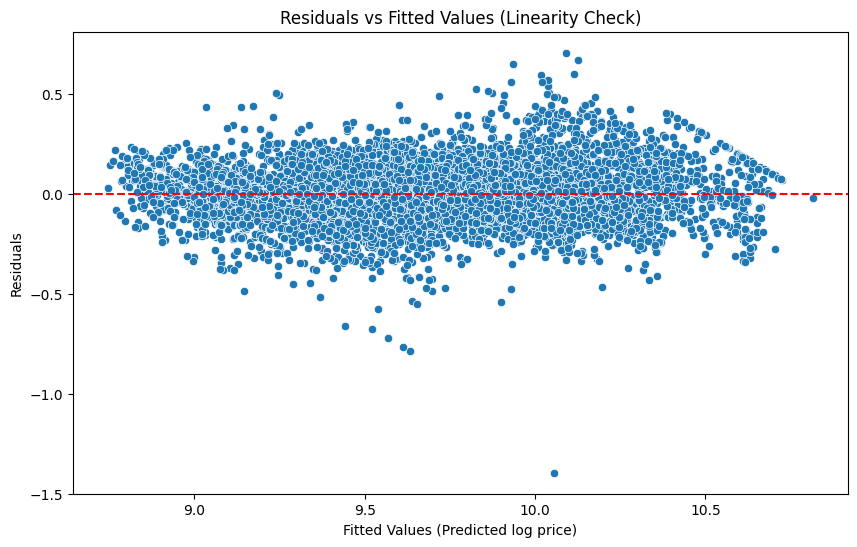

In [ ]:
y_pred_train = lr_model_1.predict(X_train)
residuals = y_train - y_pred_train

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred_train, y=residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals vs Fitted Values (Linearity Check)')
plt.xlabel('Fitted Values (Predicted log price)')
plt.ylabel('Residuals')
plt.show()

Check normality in residual distribution

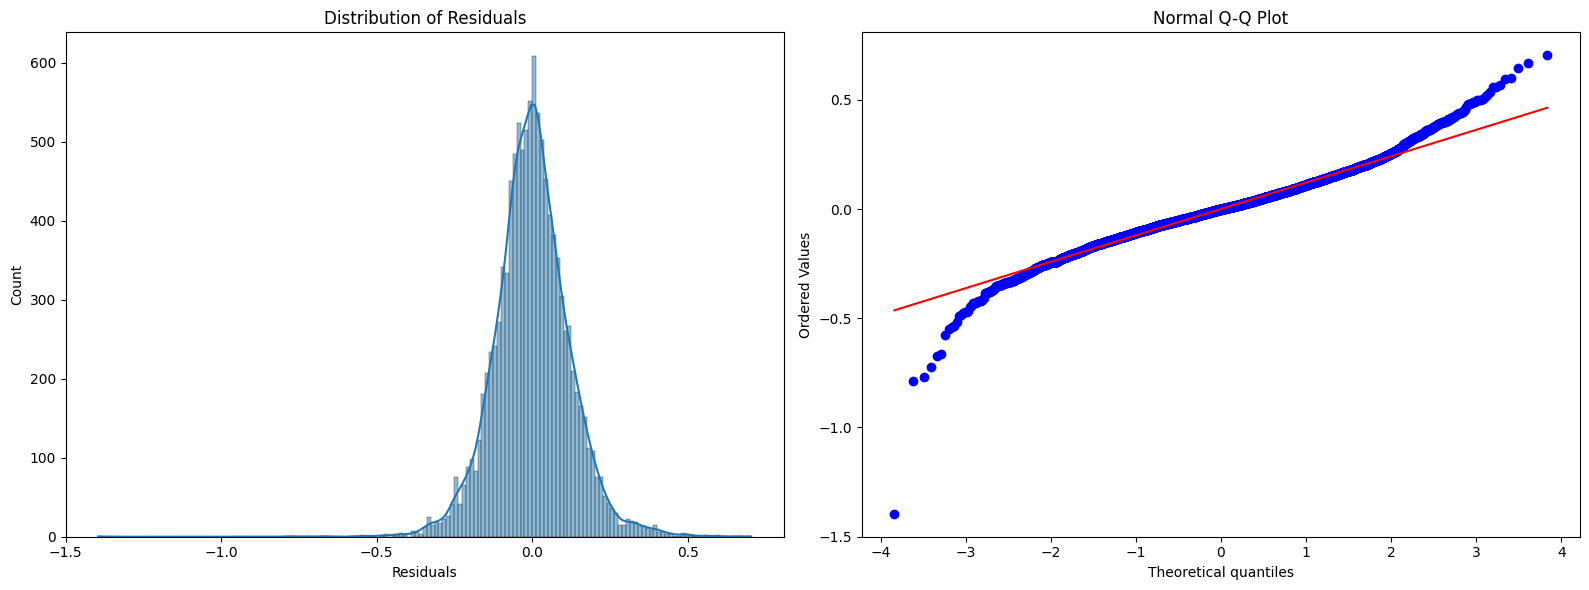

In [ ]:
import scipy.stats as stats

# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 1. Histogram of residuals
sns.histplot(residuals, kde=True, ax=ax1)
ax1.set_title('Distribution of Residuals')
ax1.set_xlabel('Residuals')

# 2. Q-Q plot
stats.probplot(residuals, dist="norm", plot=ax2)
ax2.set_title('Normal Q-Q Plot')

plt.tight_layout()
plt.show()

Check multicollinearity using Variance Inflation Factor (VIF) and handle features with high VIF.

In [ ]:
# Calculate VIF for each numerical feature
def calculate_vif(X_data):
    vif_data = pd.DataFrame()
    vif_data["feature"] = X_data.columns
    vif_data["VIF"] = [variance_inflation_factor(X_data.values, i) for i in range(len(X_data.columns))]
    return vif_data

vif_results = calculate_vif(X_train)

display(vif_results.sort_values(by='VIF', ascending=False))

,feature,VIF
61,Drive_chain_front,56.358853
53,Previous_Owners_1,28.224359
3,Weight_kg,26.271513
1,hp_kW,25.366703
2,Displacement_cc,24.832561
...,...,...
49,Gears_8,1.468152
60,Gearing_Type_Semi-automatic,1.253747
57,Paint_Type_Others,1.134990
55,Previous_Owners_3+,1.069954


In [ ]:
# Iteratively drop features with VIF > 10
def reduce_vif(X, threshold=10.0):
    X_reduced = X.copy()
    while True:
        vif_data = calculate_vif(X_reduced)
        max_vif = vif_data['VIF'].max()
        if max_vif > threshold:
            feature_to_drop = vif_data.sort_values('VIF', ascending=False)['feature'].iloc[0]
            print(f"Dropping '{feature_to_drop}' with VIF: {max_vif:.2f}")
            X_reduced = X_reduced.drop(columns=[feature_to_drop])
        else:
            break
    return X_reduced

# Apply the reduction to X_train
X_train_reduced = reduce_vif(X_train)

# Keep the same columns in validation and test sets
remaining_cols = X_train_reduced.columns
X_test_reduced = X_test[remaining_cols]

print(f"\nRemaining features: {len(remaining_cols)}")
display(calculate_vif(X_train_reduced).sort_values(by='VIF', ascending=False))

Dropping 'Drive_chain_front' with VIF: 56.36
Dropping 'Weight_kg' with VIF: 25.69
Dropping 'Previous_Owners_1' with VIF: 25.02
Dropping 'Displacement_cc' with VIF: 24.25
Dropping 'cons_comb' with VIF: 17.48
Dropping 'vat_VAT deductible' with VIF: 16.90
Dropping 'Safety_Security_Central_door_lock' with VIF: 15.46
Dropping 'Comfort_Convenience_Parking_assist_system_sensors_rear' with VIF: 13.51
Dropping 'hp_kW' with VIF: 13.24
Dropping 'Safety_Security_Electronic_stability_control' with VIF: 11.50
Dropping 'Safety_Security_Side_airbag' with VIF: 10.38

Remaining features: 51


,feature,VIF
1,Comfort_Convenience_Electrical_side_mirrors,8.036050
15,Entertainment_Media_On_board_computer,7.968689
17,Entertainment_Media_Bluetooth,7.676714
22,Extras_Alloy_wheels,7.644670
23,Safety_Security_Isofix,7.104461
35,Type_Used,7.020531
43,age_3,6.873655
25,Safety_Security_Tire_pressure_monitoring_system,6.675717
4,Comfort_Convenience_Park_Distance_Control,6.616109
16,Entertainment_Media_Radio,6.608138


## Observations
There are 11 such features which is having higher VIF >10 . Dropping them would be a good choice as these giving simmilar insight. features are as below.
* Drive_chain_front - with VIF: 56.36
* Weight_kg - with VIF: 25.69
* Previous_Owners_1 - with VIF: 25.02
* Displacement_cc - with VIF: 24.25
* cons_comb - with VIF: 17.48
* vat_VAT deductible - with VIF: 16.90
* Safety_Security_Central_door_lock - with VIF: 15.46
* Comfort_Convenience_Parking_assist_system_sensors_rear - with VIF: 13.51
* hp_kW - with VIF: 13.24
* Safety_Security_Electronic_stability_control - with VIF: 11.50
* Safety_Security_Side_airbag - with VIF: 10.38

In [ ]:
X_train_reduced.shape, X_test_reduced.shape

((11140, 51), (4775, 51))

### **3.2 Ridge Regression Implementation** <font color =red> [10 marks] </font>

#### **3.2.1** <font color =red> [2 marks] </font>
Define a list of random alpha values

In [ ]:
# List of alphas to tune for Ridge regularisation

alphas = [0.001, 0.01, 0.1, 1, 10, 100]

#### **3.2.2** <font color =red> [4 marks] </font>
Apply Ridge Regularisation and find the best value of alpha from the list

In [ ]:
# Applying Ridge regression

ridge = Ridge()
# Applying grid search cv to run through all the alphas to get the best alpha value with metric od negative MAE
model_cv=GridSearchCV(estimator=ridge,param_grid=dict(alpha=alphas),scoring = "neg_mean_absolute_error",
                        cv=5, n_jobs=-1, return_train_score=True, verbose=1)
# fiting to training features and redictor
model_cv.fit(X_train,y_train)

print(model_cv.best_estimator_.n_iter_)

Fitting 5 folds for each of 6 candidates, totalling 30 fits
None


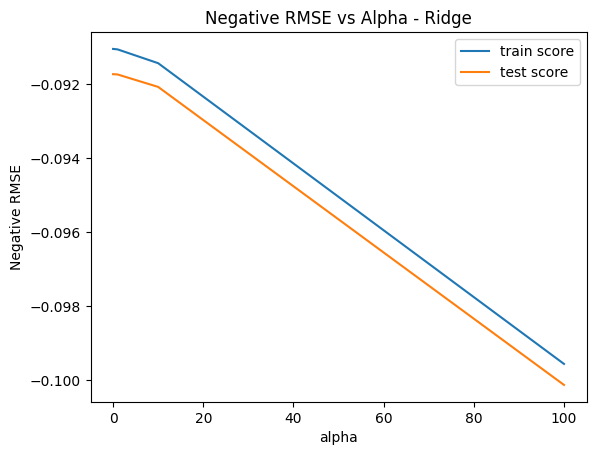

In [ ]:
# Plot train and test scores against alpha

# Convert cross-validation results to DataFrame
cv_results = pd.DataFrame(model_cv.cv_results_)

# Convert alpha to float for better plotting
cv_results['param_alpha'] = cv_results['param_alpha'].astype('float32')

# Plot train and test scores against alpha
plt.plot(cv_results['param_alpha'], cv_results['mean_train_score'])
plt.plot(cv_results['param_alpha'], cv_results['mean_test_score'])
plt.xlabel('alpha')
plt.ylabel('Negative RMSE')

plt.title("Negative RMSE vs Alpha - Ridge")
plt.legend(['train score', 'test score'], loc='upper right')
plt.show()

Find the best alpha value.

In [ ]:
# Best alpha value
best_ridge_alpha = model_cv.best_params_['alpha']
print(f"Best alpha: {best_ridge_alpha}")

# Best score (negative MAE)
best_score = model_cv.best_score_
print(f"Best negative MAE: {best_score}")


Best alpha: 0.001
Best negative MAE: -0.0917236450504747


## Observation
This shows alph value 0.001 produces the lowest average MAE on the validation folds
This Means:
* 0.01, 0.1, 1, 10, 100 : regularize too much causing overfiting

We will get some best value of alpha above. This however is not the most accurate value but the best value from the given list. Now we have a rough estimate of the range that best alpha falls in. Let us do another iteration over the values in a smaller range.

#### **3.2.3** <font color =red> [4 marks] </font>
Fine tune by taking a closer range of alpha based on the previous result.

In [ ]:
# Take a smaller range of alpha to test

param_grid = {'alpha': np.logspace(-6, -2, 30) } # 30 alphas 0.000001 to 0.01

In [ ]:
# Applying Ridge regression

ridge=Ridge()

# Apply gridserach cv for all the alphas, scoring negative MAE
model_cv=GridSearchCV(estimator=ridge,param_grid=param_grid,scoring = "neg_mean_absolute_error",
                        cv=5, n_jobs=-1, return_train_score=True, verbose=1)
model_cv.fit(X_train,y_train)

print(model_cv.best_estimator_.n_iter_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
None


Plot the error-alpha graph again and find the actual optimal value for alpha.

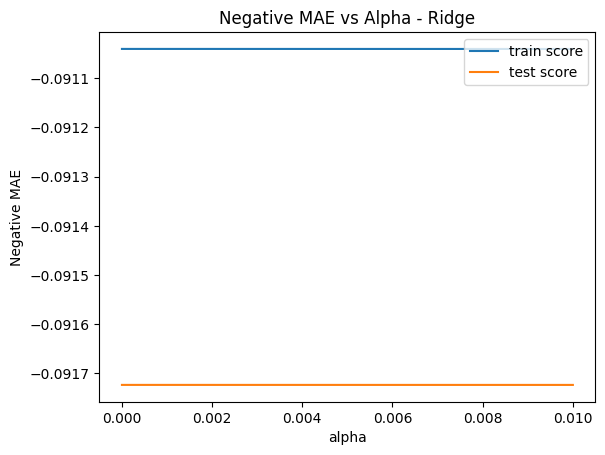

In [ ]:
# Plot train and test scores against alpha
cv_data=pd.DataFrame(model_cv.cv_results_)
cv_data['param_alpha']=cv_data['param_alpha'].astype('float32')

plt.plot(cv_data['param_alpha'], cv_data['mean_train_score'])
plt.plot(cv_data['param_alpha'], cv_data['mean_test_score'])
plt.xlabel('alpha')
plt.ylabel('Negative MAE')

plt.title("Negative MAE vs Alpha - Ridge")
plt.legend(['train score', 'test score'], loc='upper right')
plt.show()



In [ ]:
# Best alpha
best_ridge_alpha = model_cv.best_params_['alpha']
print(f"Best alpha: {best_ridge_alpha}")

# Best score (negative MAE)
best_score = model_cv.best_score_
print(f"Best negative MAE: {best_score}")

Best alpha: 1e-06
Best negative MAE: -0.0917236403382556


## Observation
The smaller range values of alpha is unable to maximize the - MAE compare to the MAE from the alpha 0.001
* alpha: 0.000001 : negative RMSE: -0.0917236403382556
* alpha: 0.001 : negative RMSE: -0.0917236450504747

The change in MAE is very negligible so its better to consider "0.001" as the optimal alpha value

In [ ]:
# Set best alpha for Ridge regression
# Fit the Ridge model to get the coefficients of the fitted model

ridge_model = Ridge(alpha=0.001)
ridge_model.fit(X_train, y_train)

Ridge(alpha=0.001)

In [ ]:
# Show the coefficients for each feature

pd.DataFrame({"Feature": X_train.columns,"Coefficients":lr_model_1.coef_, "ridge_Coefficients": ridge_model.coef_}).round(2)

,Feature,Coefficients,ridge_Coefficients
0,km,-0.33,-0.33
1,hp_kW,0.81,0.81
2,Displacement_cc,-0.21,-0.21
3,Weight_kg,0.25,0.25
4,cons_comb,0.08,0.08
...,...,...,...
57,Paint_Type_Others,-0.01,-0.01
58,Upholstery_type_Part/Full Leather,0.05,0.05
59,Gearing_Type_Manual,-0.09,-0.09
60,Gearing_Type_Semi-automatic,0.11,0.11


In [ ]:
# Evaluate the Ridge model on the test data
# Evaluate the model's performance
y_pred_lr_list = ridge_model.predict(X_train)
rmse = np.sqrt(mean_squared_error(y_true = y_train, y_pred = y_pred_lr_list))
rmse = np.round(rmse, 2)
print('Training RMSE = ', rmse)

y_pred_test_lr_list = ridge_model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_true = y_test, y_pred = y_pred_test_lr_list))
rmse = np.round(rmse, 2)
print('Validation RMSE = ', rmse)



Training RMSE =  0.12
Validation RMSE =  0.12


## Observation
After doing the Ridge regularizations, the RMSE is coming same as of the ordinary LinearRegression. the model performance is coming similar in both the cases.

### **3.3 Lasso Regression Implementation** <font color =red> [10 marks] </font>

#### **3.3.1** <font color =red> [2 marks] </font>
Define a list of random alpha values

In [ ]:
# List of alphas to tune for Lasso regularisation

alphas = [0.001, 0.01, 0.1, 1, 10, 100]

#### **3.3.2** <font color =red> [4 marks] </font>
Apply Ridge Regularisation and find the best value of alpha from the list

In [ ]:
# Initialise Lasso regression model
lasso=Lasso()

# Applying grid search
model_cv=GridSearchCV(estimator=lasso,param_grid=dict(alpha=alphas),scoring = "neg_mean_absolute_error",
                        cv=5, n_jobs=-1, return_train_score=True, verbose=1)

model_cv.fit(X_train,y_train)

print(model_cv.best_estimator_.n_iter_)


Fitting 5 folds for each of 6 candidates, totalling 30 fits
34


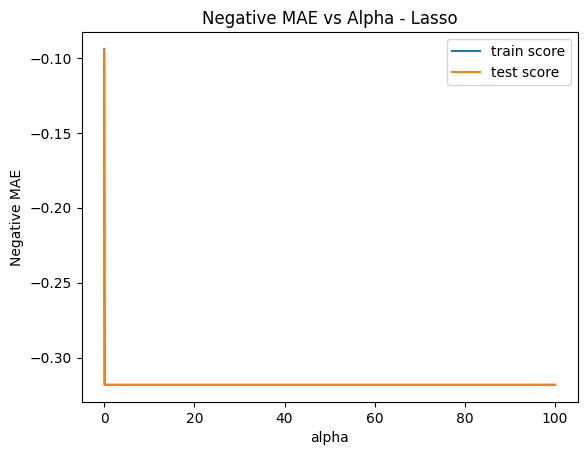

In [ ]:
# Plot train and test scores against alpha

lasso_df=pd.DataFrame(model_cv.cv_results_)
lasso_df['param_alpha']=lasso_df['param_alpha'].astype('float32')

plt.plot(lasso_df['param_alpha'], lasso_df['mean_train_score'])
plt.plot(lasso_df['param_alpha'], lasso_df['mean_test_score'])
plt.xlabel('alpha')
plt.ylabel('Negative MAE')

plt.title("Negative MAE vs Alpha - Lasso")
plt.legend(['train score', 'test score'], loc='upper right')
plt.show()

In [ ]:
# Best alpha
best_ridge_alpha = model_cv.best_params_['alpha']
print(f"Best alpha: {best_ridge_alpha}")

# Best score (negative MAE)
best_score = model_cv.best_score_
print(f"Best negative MAE: {best_score}")

Best alpha: 0.001
Best negative MAE: -0.09455216571408057


#### **3.3.3** <font color =red> [4 marks] </font>
Fine tune by taking a closer range of alpha based on the previous result.

In [ ]:
# List of alphas to tune for Lasso regularization
param_grid = {'alpha': np.logspace(-6, -2, 30) } # 30 alphas 0.000001 to 0.01


In [ ]:
# Tuning Lasso hyperparameters

lasso=Lasso()

# Applying grid search
model_cv=GridSearchCV(estimator=lasso,param_grid=param_grid,scoring = "neg_mean_absolute_error",
                        cv=5, n_jobs=-1, return_train_score=True, verbose=1)

model_cv.fit(X_train,y_train)

print(model_cv.best_estimator_.n_iter_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
65


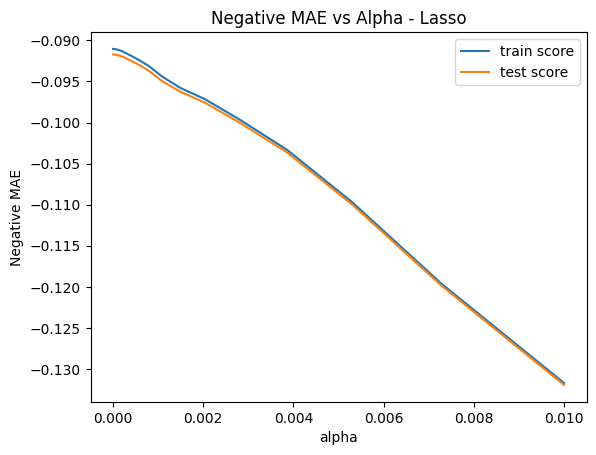

In [ ]:
# Plot train and test scores against alpha

model_cv_df=pd.DataFrame(model_cv.cv_results_)
model_cv_df['param_alpha']=model_cv_df['param_alpha'].astype('float32')

plt.plot(model_cv_df['param_alpha'], model_cv_df['mean_train_score'])
plt.plot(model_cv_df['param_alpha'], model_cv_df['mean_test_score'])
plt.xlabel('alpha')
plt.ylabel('Negative MAE')

plt.title("Negative MAE vs Alpha - Lasso")
plt.legend(['train score', 'test score'], loc='upper right')
plt.show()

In [ ]:
# Best alpha
best_ridge_alpha = model_cv.best_params_['alpha']
print(f"Best alpha: {best_ridge_alpha}")

# Best score (negative MAE)
best_score = model_cv.best_score_
print(f"Best negative MAE: {best_score}")

Best alpha: 1e-06
Best negative MAE: -0.09172373440150325


## Observation
The smaller range values of alpha is unable to maximize the - MAE compare to the MAE from the alpha 0.001
* alpha: 0.000001 : negative RMSE: -0.09172373440150325
* alpha: 0.001 : negative RMSE: -0.09455216571408057

The change in MAE is very negligible so its better to consider "0.001" as the optimal alpha value

In [ ]:
# Set best alpha for Lasso regression
best_alpha=0.001


# Fit the Lasso model on scaled training data
lasso_model = Lasso(alpha=best_alpha)
lasso_model.fit(X_train, y_train)



Lasso(alpha=0.001)

In [ ]:
# Check the coefficients for each feature

pd.DataFrame({"Feature": X_train.columns, "Coefficients": lasso_model.coef_}).round(2)

,Feature,Coefficients
0,km,-0.33
1,hp_kW,0.74
2,Displacement_cc,-0.03
3,Weight_kg,0.27
4,cons_comb,0.00
...,...,...
57,Paint_Type_Others,-0.00
58,Upholstery_type_Part/Full Leather,0.05
59,Gearing_Type_Manual,-0.10
60,Gearing_Type_Semi-automatic,0.07


In [ ]:
# Evaluate the Lasso model on the test data
y_pred_lr_list = lasso_model.predict(X_train)
rmse = np.sqrt(mean_squared_error(y_true = y_train, y_pred = y_pred_lr_list))
rmse = np.round(rmse, 2)
print('Training RMSE = ', rmse)

y_pred_test_lr_list = lasso_model.predict(X_test)
rmse= np.sqrt(mean_squared_error(y_true = y_test, y_pred = y_pred_test_lr_list))
rmse = np.round(rmse, 2)
print('Validation RMSE = ', rmse)


Training RMSE =  0.13
Validation RMSE =  0.13


### **3.4 Regularisation Comparison & Analysis** <font color =red> [5 marks] </font>

#### **3.4.1** <font color =red> [2 marks] </font>
Compare the evaluation metrics for each model.

In [ ]:
# Compare metrics for each model
def get_metrics(model, X_train, y_train, X_test, y_test, model_name):
    # Predictions
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    # Metrics
    train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    train_r2 = r2_score(y_train, y_pred_train)
    test_r2 = r2_score(y_test, y_pred_test)

    return pd.Series({
        'Train RMSE': train_rmse,
        'Test RMSE': test_rmse,
        'Train R2': train_r2,
        'Test R2': test_r2
    }, name=model_name)

# Collect metrics for all models
lr_metrics = get_metrics(lr_model_1, X_train, y_train, X_test, y_test, 'Linear Regression')
ridge_metrics = get_metrics(ridge_model, X_train, y_train, X_test, y_test, 'Ridge (Alpha=0.001)')
lasso_metrics = get_metrics(lasso_model, X_train, y_train, X_test, y_test, 'Lasso (Alpha=0.001)')

# Create comparison table
comparison_df = pd.DataFrame([lr_metrics, ridge_metrics, lasso_metrics])
display(comparison_df.round(4))

,Train RMSE,Test RMSE,Train R2,Test R2
Linear Regression,0.1222,0.1228,0.9050,0.9046
Ridge (Alpha=0.001),0.1222,0.1228,0.9050,0.9046
Lasso (Alpha=0.001),0.1254,0.1255,0.8999,0.9004


#### **3.4.2** <font color =red> [3 marks] </font>
Compare the coefficients for the three models.

Also visualise a few of the largest coefficients and the coefficients of features dropped by Lasso.

In [ ]:
# Create a DataFrame to compare coefficients
coef_comparison = pd.DataFrame({
    'Feature': X_train.columns,
    'Linear Regression': lr_model_1.coef_,
    'Ridge': ridge_model.coef_,
    'Lasso': lasso_model.coef_
})

# Identify features dropped by Lasso (coefficient is exactly 0)
dropped_by_lasso = coef_comparison[coef_comparison['Lasso'] == 0]['Feature'].tolist()

print(f"Number of features eliminated by Lasso: {len(dropped_by_lasso)}")
print(f"Eliminated features: {dropped_by_lasso}")

# Display the top 10 most influential features based on Lasso
print("\nTop 10 features by Lasso absolute coefficient value:")
display(coef_comparison.reindex(coef_comparison.Lasso.abs().sort_values(ascending=False).index).head(10).round(4))

Number of features eliminated by Lasso: 16
Eliminated features: ['cons_comb', 'Comfort_Convenience_Multi_function_steering_wheel', 'Comfort_Convenience_Parking_assist_system_sensors_rear', 'Entertainment_Media_Radio', 'Entertainment_Media_Bluetooth', 'Safety_Security_Tire_pressure_monitoring_system', 'Safety_Security_LED_Daytime_Running_Lights', 'body_type_Sedans', 'body_type_Station wagon', 'vat_VAT deductible', 'Fuel_Other', 'Previous_Owners_1', 'Previous_Owners_2', 'Previous_Owners_3+', 'Paint_Type_Others', 'Drive_chain_front']

Top 10 features by Lasso absolute coefficient value:


,Feature,Linear Regression,Ridge,Lasso
1,hp_kW,0.8064,0.8064,0.7410
0,km,-0.3297,-0.3297,-0.3287
39,make_model_Renault,-0.3235,-0.3234,-0.2892
38,make_model_Opel,-0.3001,-0.3001,-0.2889
3,Weight_kg,0.2477,0.2477,0.2663
52,age_3,-0.2578,-0.2578,-0.2444
51,age_2,-0.1959,-0.1959,-0.1813
40,body_type_Other,0.1938,0.1938,0.1464
50,age_1,-0.1327,-0.1327,-0.1194
59,Gearing_Type_Manual,-0.0892,-0.0892,-0.1042


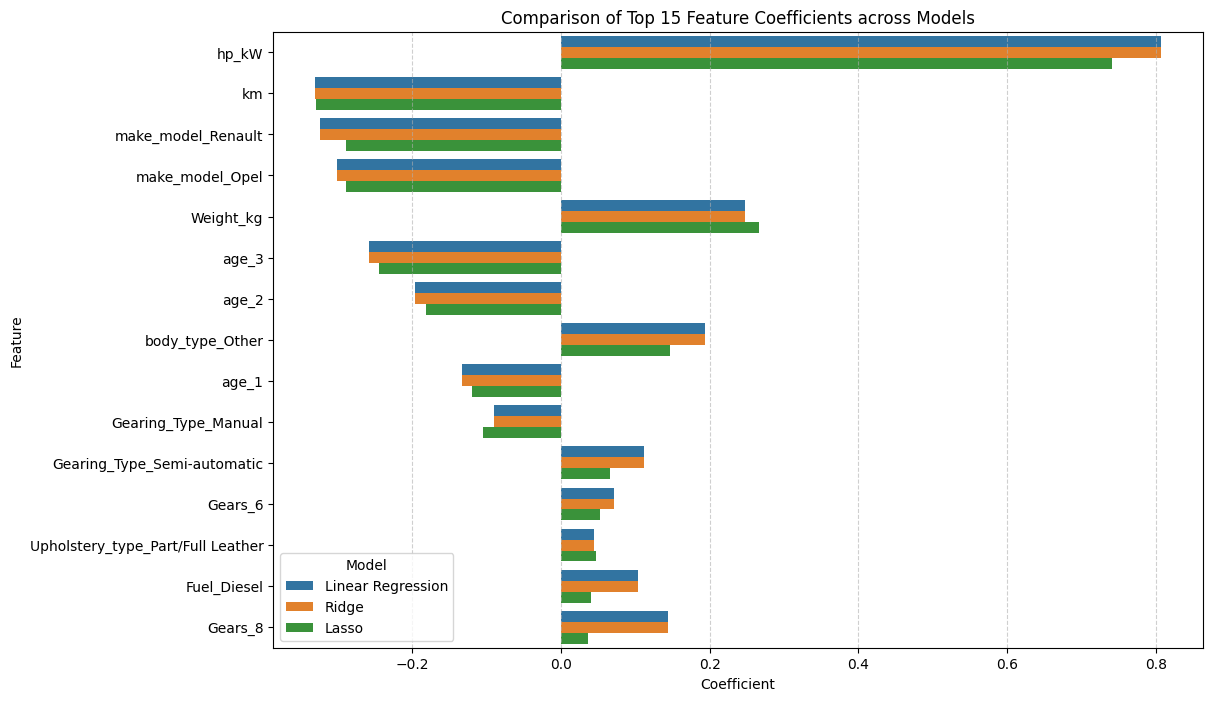

In [ ]:
# Visualizing the coefficients comparison for the top 15 features
top_features = coef_comparison.reindex(coef_comparison.Lasso.abs().sort_values(ascending=False).index).head(15)

plt.figure(figsize=(12, 8))
top_features_melted = top_features.melt(id_vars='Feature', var_name='Model', value_name='Coefficient')
sns.barplot(data=top_features_melted, y='Feature', x='Coefficient', hue='Model')
plt.title('Comparison of Top 15 Feature Coefficients across Models')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

### **Obseravtion**
from the above visualisation of the top 15 features, it is concluded that how the regularization affects the importance of the feature.
* Allmost every feature Lasso did a freat job in giving proper weightage.
* Where as basic linear and ridge model treats the feature in a simmilar fashion.
* Also Lasso makes coeficints of less important features 0 which we can eliminate.
* Simillar to VIF, where we removed the features based on the multicolinearity checks

## **4 Conclusion & Key Takeaways**  <font color =red> [10 marks] </font>

What did you notice by performing regularisation? Did the model performance improve? If not, then why? Did you find overfitting or not? Was the data sufficent? Is a linear model sufficient?

#### 1. Impact of Regularisation
* **Model Performance:** We observed that Linear Regression, Ridge, and Lasso yielded almost identical RMSE (~ 0.12) and $R^2$ (~ 0.90) values. This is primarily because the optimal alpha values chosen via GridSearch were very low (0.001), meaning the penalty was light, and the underlying data already followed a strong linear trend.
* **Feature Selection (Lasso):** Lasso regression effectively simplified the model by setting **16 feature coefficients to zero**. Features like cons_comb, Drive_chain_front, and specific Previous_Owners categories were eliminated, improving model interpretability without sacrificing accuracy.

#### 2. Overfitting Analysis
* There was **no significant evidence of overfitting**. The gap between Training RMSE (0.12) and Validation RMSE (0.12) was negligible.

#### 3. Data Sufficiency & Model Choice
* **Data Quality:** The dataset was sufficient for this task. The high $R^2$ score indicates that ~90% of the variance in (log) car prices is explained by the features provided, such as engine power (`hp_kW`), mileage (`km`), and vehicle age.
* **Linear Model Suitability:** A linear model is **highly sufficient** for this dataset. The residual diagnostics (histogram and Q-Q plots) showed that errors are approximately normally distributed, and the scatter plot of residuals indicated that the relationship between features and the target is predominantly linear.

#### **4.1 Conclude with outcomes and insights gained** <font color =red> [10 marks] </font>


#### **Key Takeaway**
* While regularization didn't drastically lower the error, it validated our baseline model and identified the most critical price drivers: engine performance and usage (mileage/age).
* feture engineering from the multivalued categorical variable helped to add more intutivity towards the prediction of car price.
* The underlying data is following a linear trend for which even the basic linear regression model performs well without the regularization.
* However, regularizarions with the optimal alpha determination through Gridsearch Cv helps in validating the outcomes from basic liner model.